*Notebook description*: this notebook contains the analysis of the full HOX KO segmentoid sample. 

## Loading data 



In [1]:
# USE ENVIRONMENT TEXTENV

In [2]:
!conda info --envs

# conda environments:
#
base                     C:\Users\aleja\anaconda3
singlecellEnv            C:\Users\aleja\anaconda3\envs\singlecellEnv
textenv               *  C:\Users\aleja\anaconda3\envs\textenv



In [3]:
import os

In [4]:
os. getcwd() 

'D:\\BIOINFO\\POURQUIE\\HOX_project\\Analysis_SCANPY'

In [5]:
import numpy as np
import pandas as pd
import scanpy as sc

In [6]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()  #updated scanpy to 1.10
sc.settings.set_figure_params(dpi=80, facecolor='white')

-----
anndata     0.10.7
scanpy      1.10.0
-----
PIL                         8.4.0
anyio                       NA
arrow                       1.3.0
asttokens                   NA
attr                        23.2.0
attrs                       23.2.0
babel                       2.14.0
backcall                    0.2.0
bottleneck                  1.3.7
brotli                      NA
certifi                     2024.08.30
cffi                        1.16.0
chardet                     5.2.0
charset_normalizer          3.3.2
cloudpickle                 3.0.0
colorama                    0.4.6
comm                        0.2.1
cycler                      0.12.1
cython_runtime              NA
cytoolz                     0.12.3
dask                        2024.2.0
dateutil                    2.8.2
debugpy                     1.8.1
decorator                   5.1.1
defusedxml                  0.7.1
exceptiongroup              1.2.0
executing                   2.0.1
fastjsonschema              NA

In [7]:
adata = sc.read_10x_mtx(
    'D:/BIOINFO/POURQUIE/HOX_project/Third_batch/HOXKO/filtered_feature_bc_matrix',  # the directory with the `.mtx` file
    var_names='gene_symbols',                # use gene symbols for the variable names (variables-axis index)
    cache=True) 

... reading from cache file cache\D-BIOINFO-POURQUIE-HOX_project-Third_batch-HOXKO-filtered_feature_bc_matrix-matrix.h5ad


In [8]:
adata.var_names_make_unique()

In [9]:
# add some metadata
adata.obs['sample']="HOX_KO"

In [10]:
print(adata.obs['sample'].value_counts())

adata 

sample
HOX_KO    4508
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 4508 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [11]:
print(adata.X)

  (26, 3)	1.0
  (69, 3)	1.0
  (203, 3)	1.0
  (223, 3)	1.0
  (232, 3)	1.0
  (258, 3)	1.0
  (322, 3)	1.0
  (325, 3)	1.0
  (344, 3)	1.0
  (398, 3)	1.0
  (459, 3)	1.0
  (547, 3)	1.0
  (559, 3)	1.0
  (646, 3)	1.0
  (696, 3)	1.0
  (779, 3)	1.0
  (791, 3)	1.0
  (992, 3)	1.0
  (1239, 3)	1.0
  (1254, 3)	1.0
  (1361, 3)	1.0
  (1366, 3)	1.0
  (1377, 3)	1.0
  (1418, 3)	1.0
  (1453, 3)	1.0
  :	:
  (4015, 36599)	1.0
  (4025, 36599)	1.0
  (4077, 36599)	1.0
  (4112, 36599)	1.0
  (4133, 36599)	1.0
  (4167, 36599)	2.0
  (4178, 36599)	1.0
  (4191, 36599)	1.0
  (4200, 36599)	1.0
  (4207, 36599)	1.0
  (4208, 36599)	1.0
  (4239, 36599)	1.0
  (4245, 36599)	1.0
  (4279, 36599)	1.0
  (4282, 36599)	1.0
  (4380, 36599)	1.0
  (4382, 36599)	1.0
  (4383, 36599)	1.0
  (4423, 36599)	1.0
  (4479, 36599)	1.0
  (4490, 36599)	1.0
  (281, 36600)	1.0
  (695, 36600)	1.0
  (806, 36600)	1.0
  (3401, 36600)	1.0


# Preprocessing

In [12]:
# mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-') 
# ribosomal genes
adata.var['ribo'] = adata.var_names.str.startswith(("RPS","RPL"))
# hemoglobin genes.
adata.var['hb'] = adata.var_names.str.contains(("^HB[^(P)]"))


In [13]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt','ribo','hb'], percent_top=None, log1p=False, inplace=True)

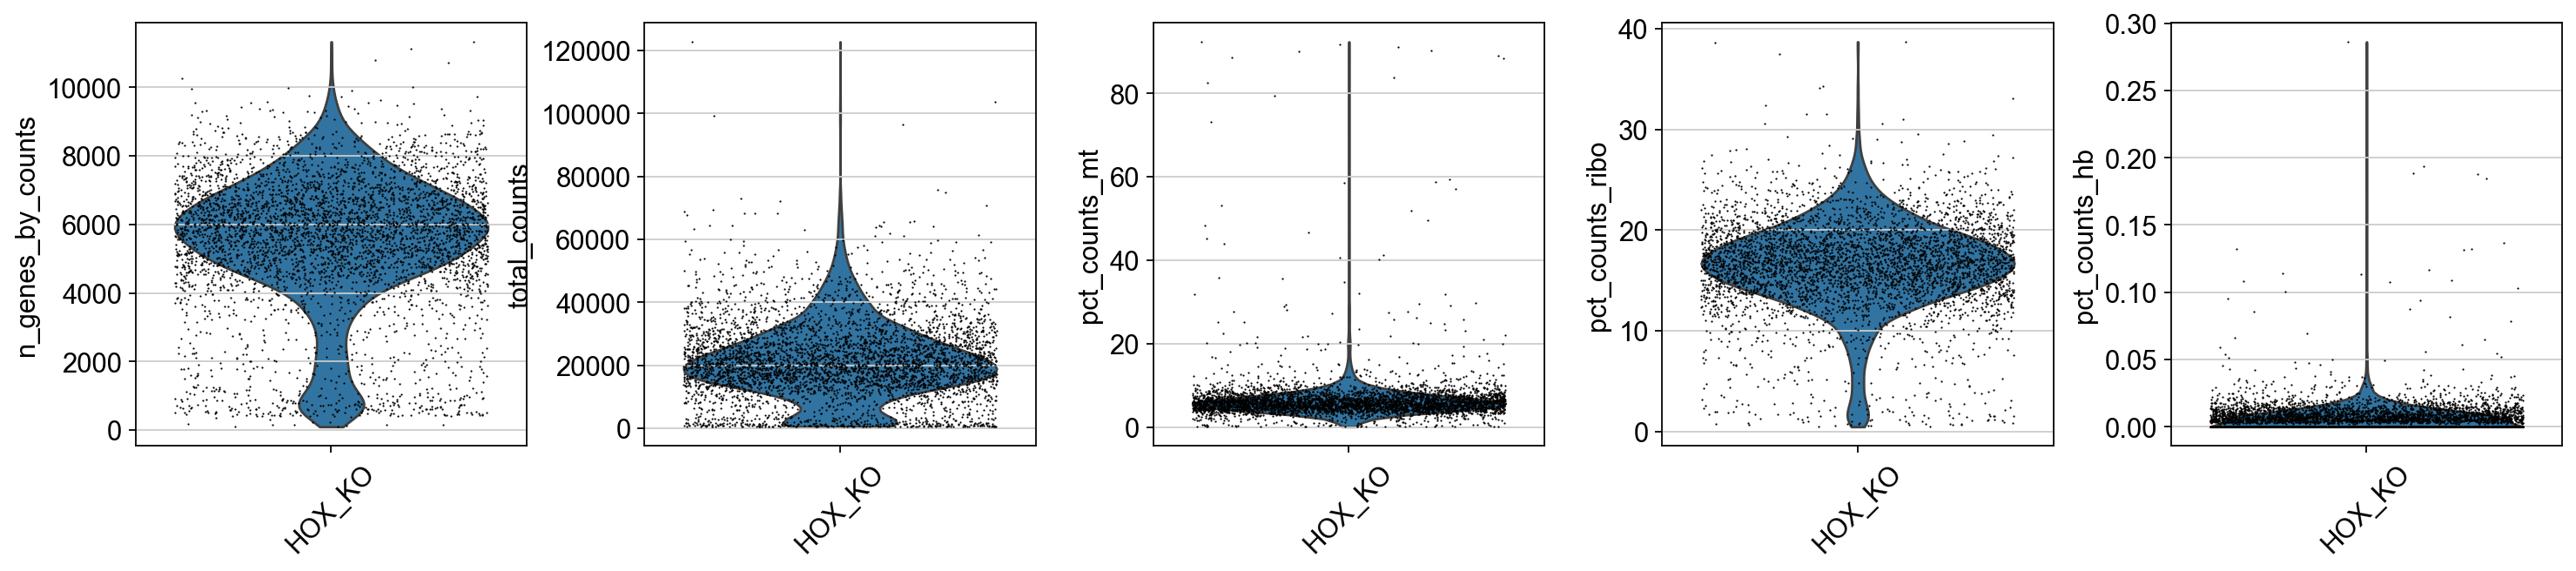

In [14]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt','pct_counts_ribo', 'pct_counts_hb'],
             jitter=0.4, groupby = 'sample', rotation= 45)

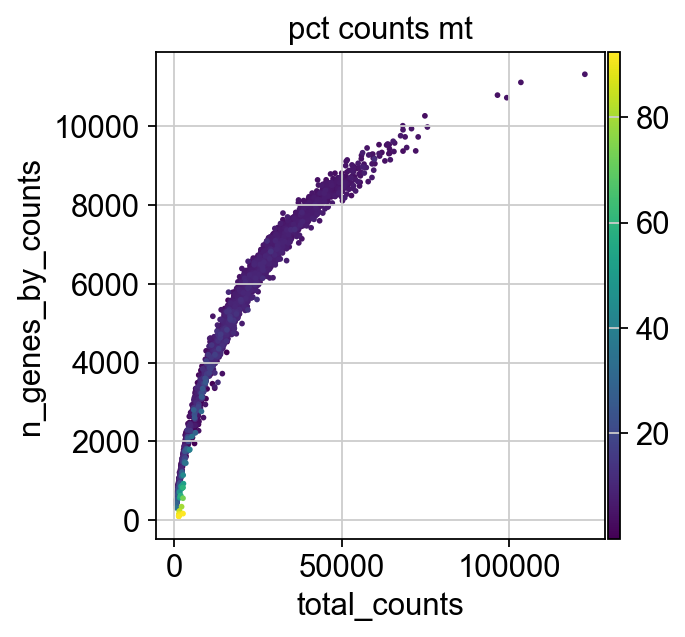

In [15]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## Filtering

In [16]:
sc.pp.filter_cells(adata, min_genes=1000)  
sc.pp.filter_genes(adata, min_cells=3)

print(adata.n_obs, adata.n_vars)

filtered out 228 cells that have less than 1000 genes expressed
filtered out 9265 genes that are detected in less than 3 cells
4280 27336


normalizing counts per cell
    finished (0:00:00)


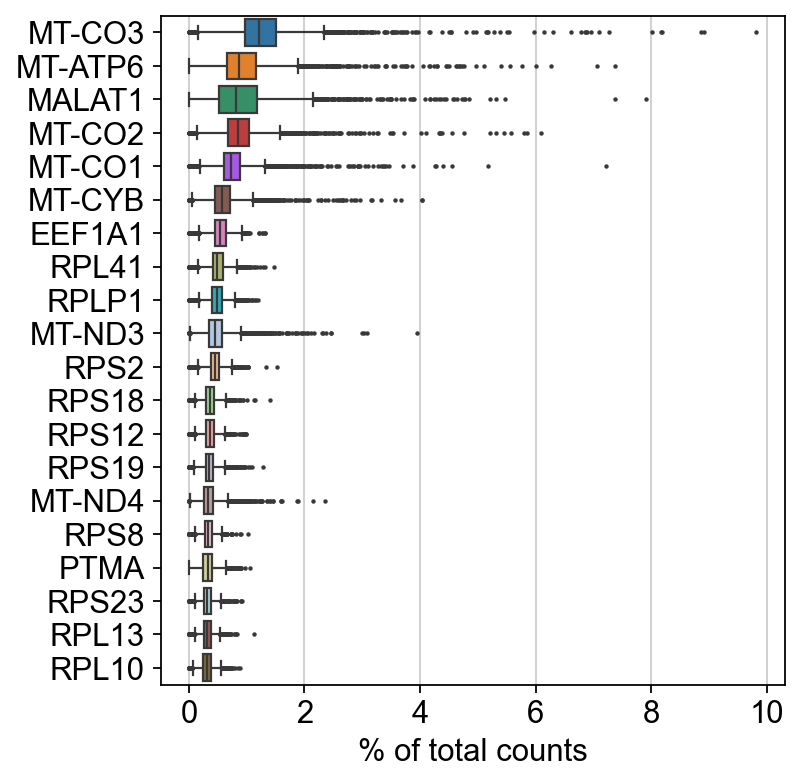

In [17]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [18]:
# filter for percent mito
adata = adata[adata.obs['pct_counts_mt'] < 20, :]
adata = adata[adata.obs['pct_counts_ribo'] > 5, :].copy()

print("Remaining cells %d"%adata.n_obs)

Remaining cells 4181


In [19]:
print(adata.obs['sample'].value_counts())

sample
HOX_KO    4181
Name: count, dtype: int64


In [20]:
malat1 = adata.var_names.str.startswith('MALAT1')
mito_genes = adata.var_names.str.startswith('MT-')
ribo_genes =adata.var_names.str.startswith(("RPS","RPL"))

remove = mito_genes | malat1 | ribo_genes
keep = np.invert(remove)

adata = adata[:,keep].copy()

normalizing counts per cell
    finished (0:00:00)


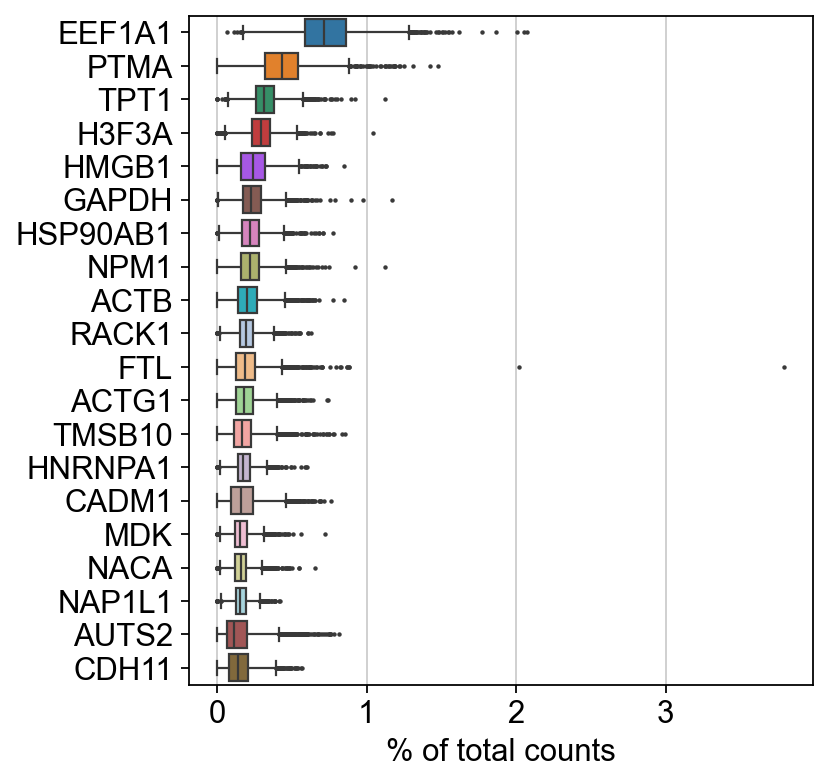

In [21]:
sc.pl.highest_expr_genes(adata, n_top=20)

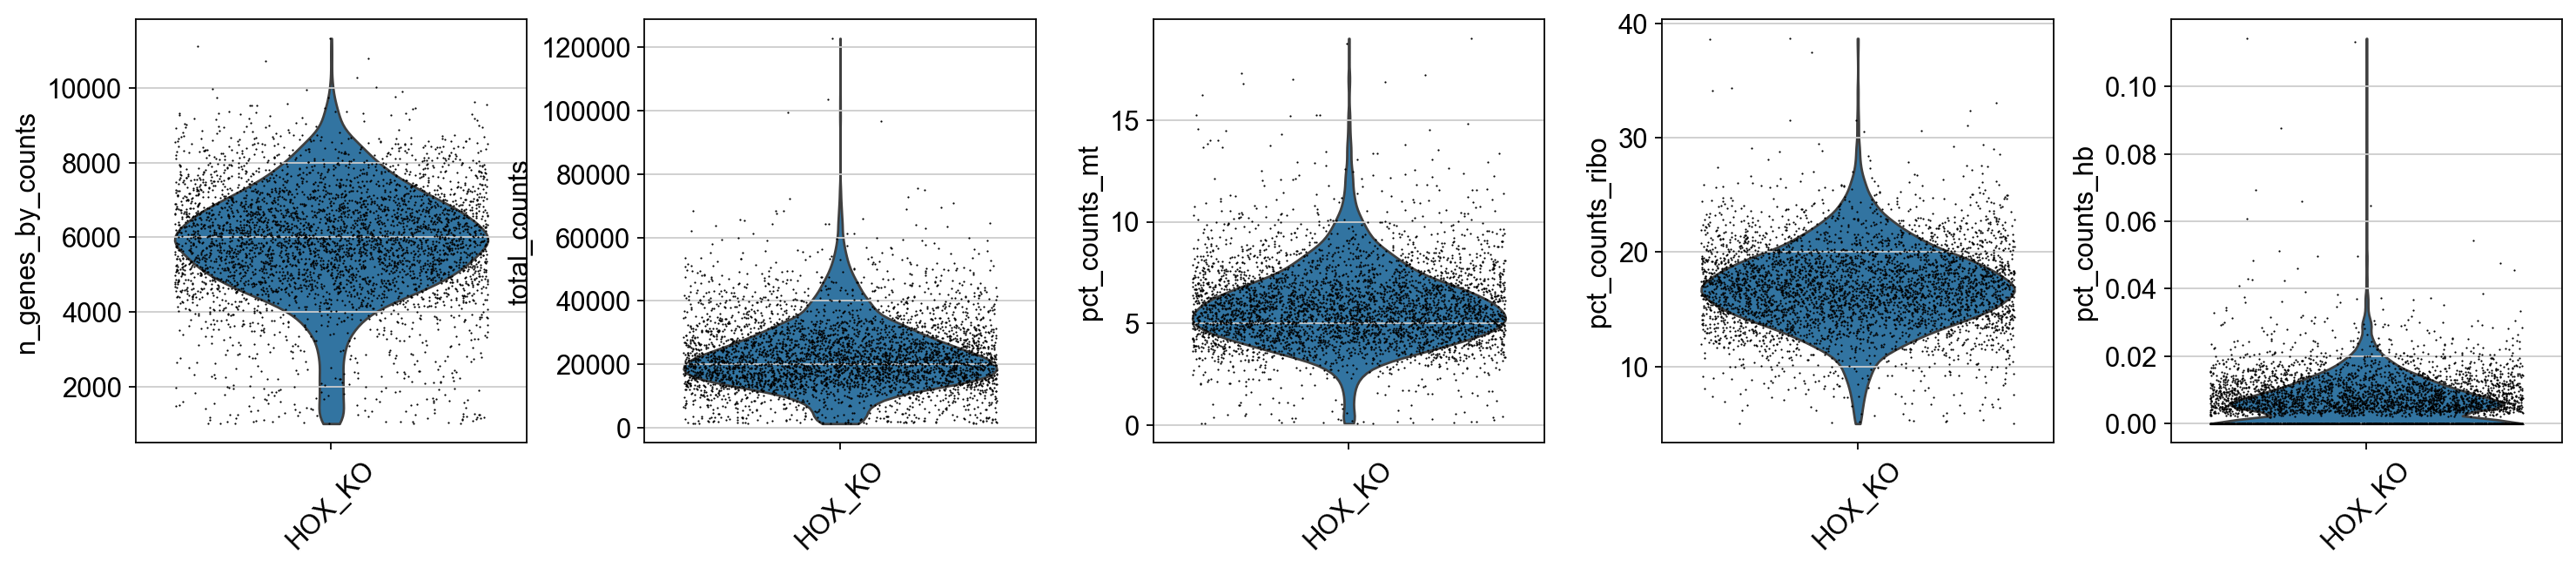

In [22]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt','pct_counts_ribo', 'pct_counts_hb'],
             jitter=0.4, groupby = 'sample', rotation= 45)

## Doublet detection

Doblet prediction should be run on raw counts

In [23]:
sc.pp.scrublet(adata,expected_doublet_rate=0.04, threshold=0.20) #threshold visually established

Running Scrublet
filtered out 43 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Detected doublet rate = 1.4%
Estimated detectable doublet fraction = 26.8%
Overall doublet rate:
	Expected   = 4.0%
	Estimated  = 5.1%
    Scrublet finished (0:00:43)


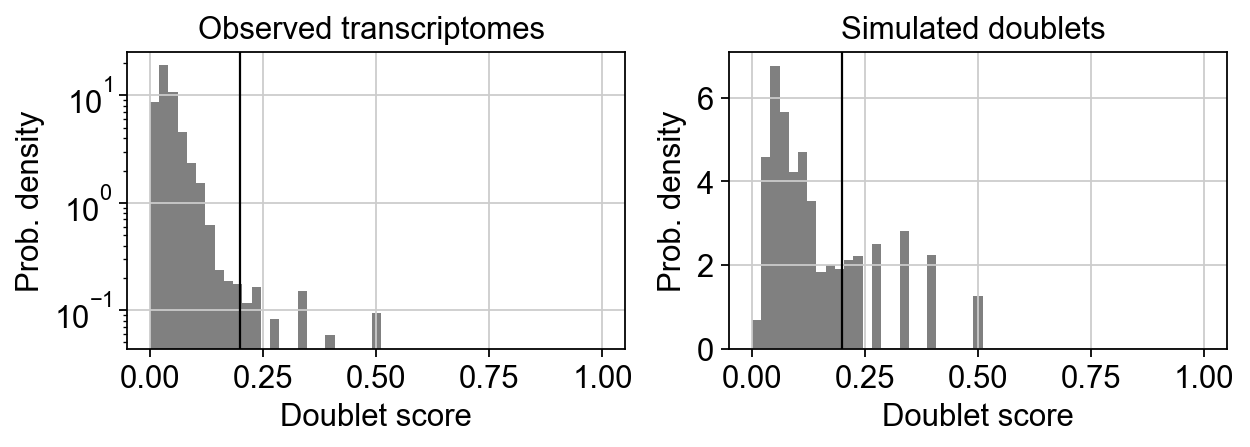

In [24]:
sc.pl.scrublet_score_distribution(adata)

In [25]:
sum(adata.obs['predicted_doublet'])

57

In [26]:
adata= adata[adata.obs['predicted_doublet'] == False,:].copy()
print(adata.shape)

(4124, 27222)


## Calculate cell-cycle scores

In [27]:
cell_cycle_genes = [x.strip() for x in open('./regev_lab_cell_cycle_genes.txt')]
print(len(cell_cycle_genes))

# Split into 2 lists
s_genes = cell_cycle_genes[:43]
g2m_genes = cell_cycle_genes[43:]

cell_cycle_genes = [x for x in cell_cycle_genes if x in adata.var_names]
print(len(cell_cycle_genes))

97
94


In [28]:
#Store raw data 
adata.layers["raw_counts"] = adata.X.copy()

In [29]:
# normalize to depth 10 000
sc.pp.normalize_total(adata, target_sum=1e4)

# logaritmize
sc.pp.log1p(adata)

# save lognorm counts in raw slot.
adata.raw = adata.copy()


normalizing counts per cell
    finished (0:00:00)


In [30]:
print(adata.raw.X[1:10,1:10]) 

  (1, 0)	0.42701777815818787
  (4, 3)	0.6657679080963135
  (7, 3)	0.44470882415771484
  (2, 4)	0.6416028738021851
  (5, 5)	0.5139382481575012


In [31]:
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)

calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    344 total control genes are used. (0:00:00)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    341 total control genes are used. (0:00:00)
-->     'phase', cell cycle phase (adata.obs)


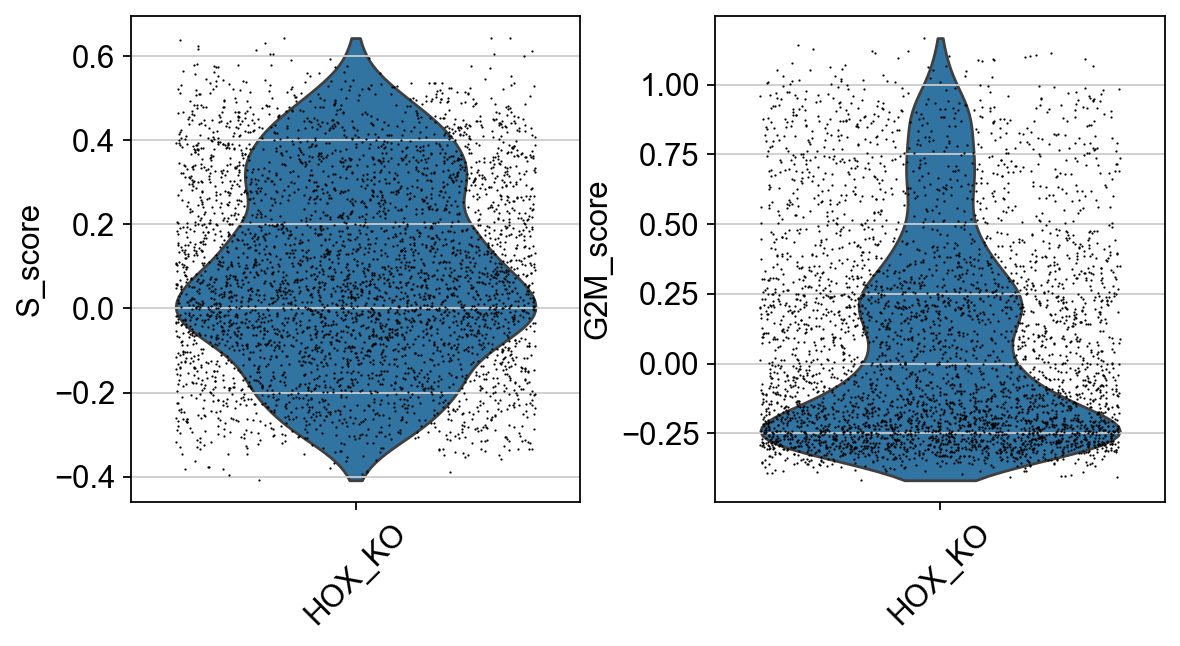

In [32]:
sc.pl.violin(adata, ['S_score', 'G2M_score'],
             jitter=0.4, groupby = 'sample', rotation=45)

In [33]:
save_file = 'H5AD/20241113_HOXKO_qc_filtered.h5ad'
adata.write_h5ad(save_file)

## DIMENSION REDUCTION

In [34]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()

In [35]:
sc.settings.set_figure_params(dpi=80)

In [36]:
adata = sc.read_h5ad('H5AD/20241113_HOXKO_qc_filtered.h5ad')

The data has been already normalized and log.

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Highly variable genes: 4114


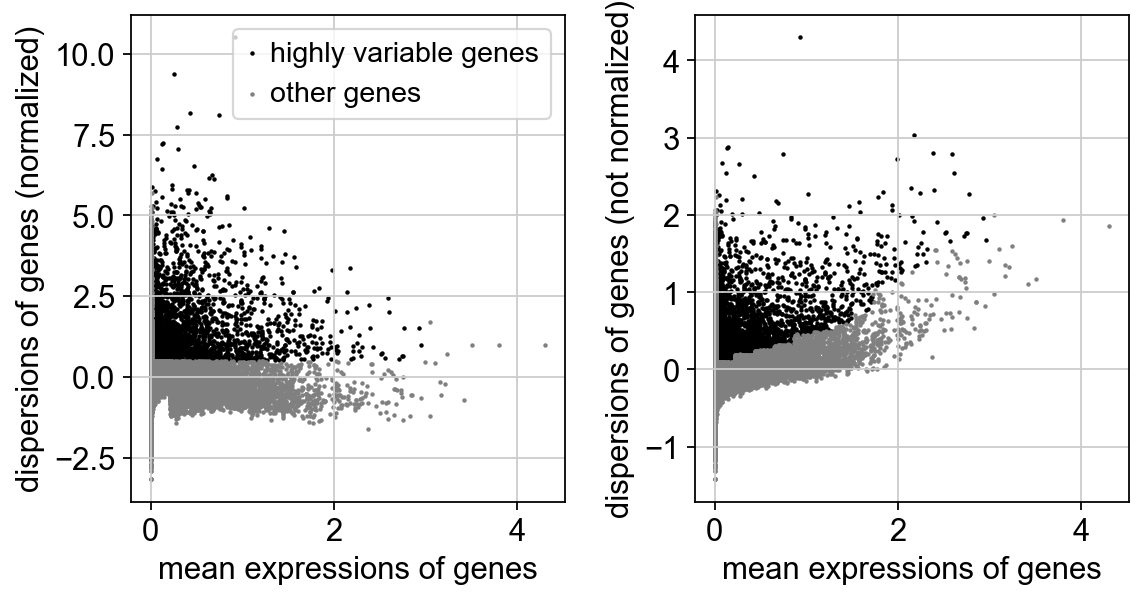

In [37]:
# compute variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
print("Highly variable genes: %d"%sum(adata.var.highly_variable))

#plot variable genes
sc.pl.highly_variable_genes(adata)

adata = adata[:, adata.var['highly_variable']].copy()

### PCA

In [38]:
# regress out unwanted variables
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt','S_score', 'G2M_score'])

# scale data, clip values exceeding standard deviation 10.
sc.pp.scale(adata, max_value=10)

regressing out ['total_counts', 'pct_counts_mt', 'S_score', 'G2M_score']
    sparse input is densified and may lead to high memory use
    finished (0:00:22)


In [39]:
print(adata.raw.X[1:10,1:10]) 

  (1, 0)	0.42701777815818787
  (4, 3)	0.6657679080963135
  (7, 3)	0.44470882415771484
  (2, 4)	0.6416028738021851
  (5, 5)	0.5139382481575012


In [40]:
sc.tl.pca(adata, svd_solver='arpack')

computing PCA
    with n_comps=50
    finished (0:00:03)


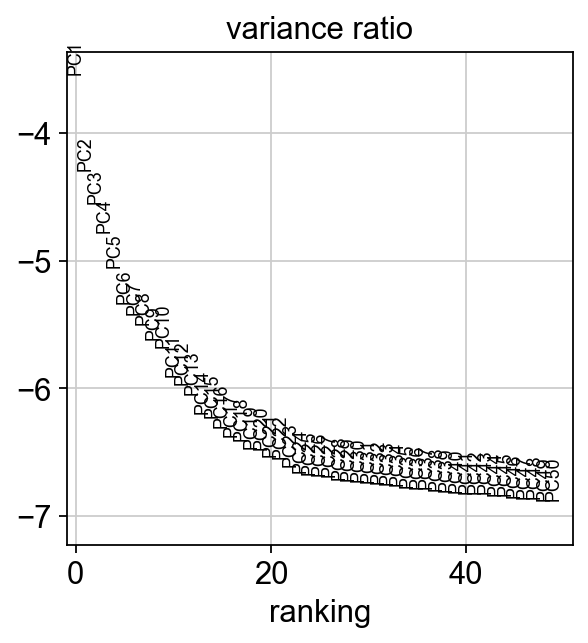

In [41]:
sc.pl.pca_variance_ratio(adata, log=True, n_pcs = 50)

### tSNE and UMAP

In [42]:
sc.tl.tsne(adata, n_pcs = 50)

computing tSNE
    using 'X_pca' with n_pcs = 50
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm) (0:00:23)


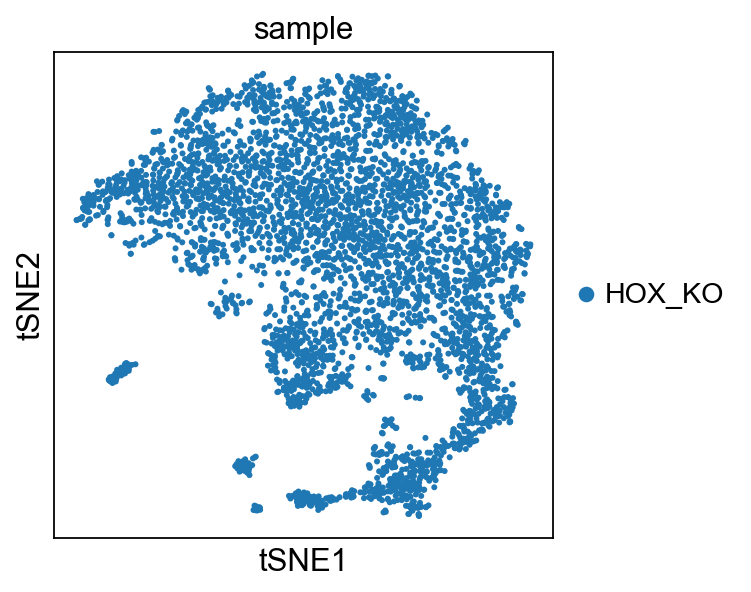

In [43]:
sc.pl.tsne(adata, color='sample')

In [44]:
sc.pp.neighbors(adata, n_pcs = 50, n_neighbors = 5)  

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)


In [45]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:04)


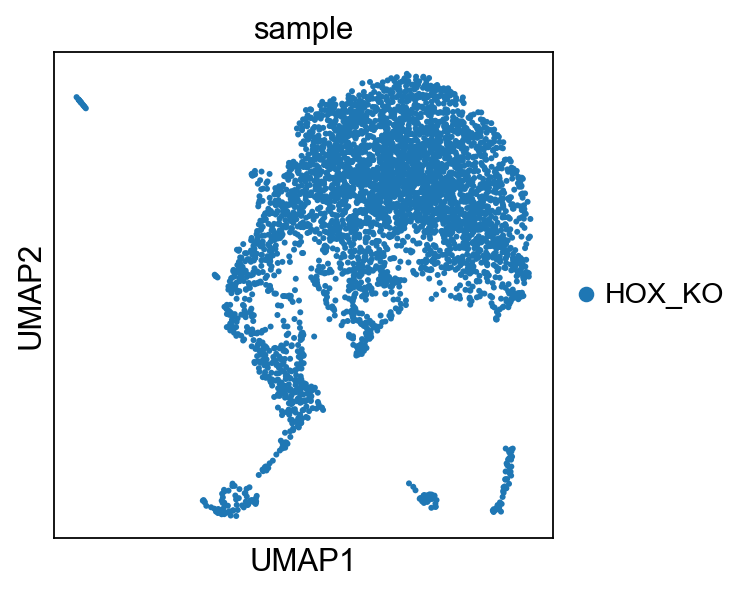

In [46]:
sc.pl.umap(adata, color='sample')

In [47]:
print(adata.X.shape)  # contains the variable genes, scaled and corrected
print(adata.raw.X.shape)  #contains all genes, normalized and log 

(4124, 4114)
(4124, 27222)


*Optional*: you can proceed without doing this, but remember to set Use_raw=True for downstream analysis. 

In [48]:
adata = adata.raw.to_adata() 

# check that the matrix looks like normalized counts
print(adata.X[1:10,1:10])

  (1, 0)	0.42701777815818787
  (4, 3)	0.6657679080963135
  (7, 3)	0.44470882415771484
  (2, 4)	0.6416028738021851
  (5, 5)	0.5139382481575012


In [49]:
adata #we lost some variables

AnnData object with n_obs × n_vars = 4124 × 27222
    obs: 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'log1p', 'sample_colors', 'scrublet', 'hvg', 'pca', 'tsne', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'distances', 'connectivities'

In [50]:
save_file = 'H5AD/20241113_HOXKO_qc_filtered_dr.h5ad'
adata.write_h5ad(save_file)

## Clustering

In [51]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()

In [52]:
sc.settings.set_figure_params(dpi=80)

In [53]:
save_file = 'H5AD/20241113_HOXKO_qc_filtered_dr.h5ad'
adata = sc.read_h5ad(save_file)

In [54]:
adata.raw = adata.copy() 

In [55]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


## Leiden

In [56]:
sc.tl.leiden(adata, resolution = 0.1, key_added = "leiden_0.1")
sc.tl.leiden(adata, resolution = 0.2, key_added = "leiden_0.2")
sc.tl.leiden(adata, resolution = 0.3, key_added = "leiden_0.3")

running Leiden clustering
    finished: found 6 clusters and added
    'leiden_0.1', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering


C:\Users\aleja\AppData\Local\Temp\ipykernel_18988\1483163260.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.1, key_added = "leiden_0.1")


    finished: found 9 clusters and added
    'leiden_0.2', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 10 clusters and added
    'leiden_0.3', the cluster labels (adata.obs, categorical) (0:00:00)


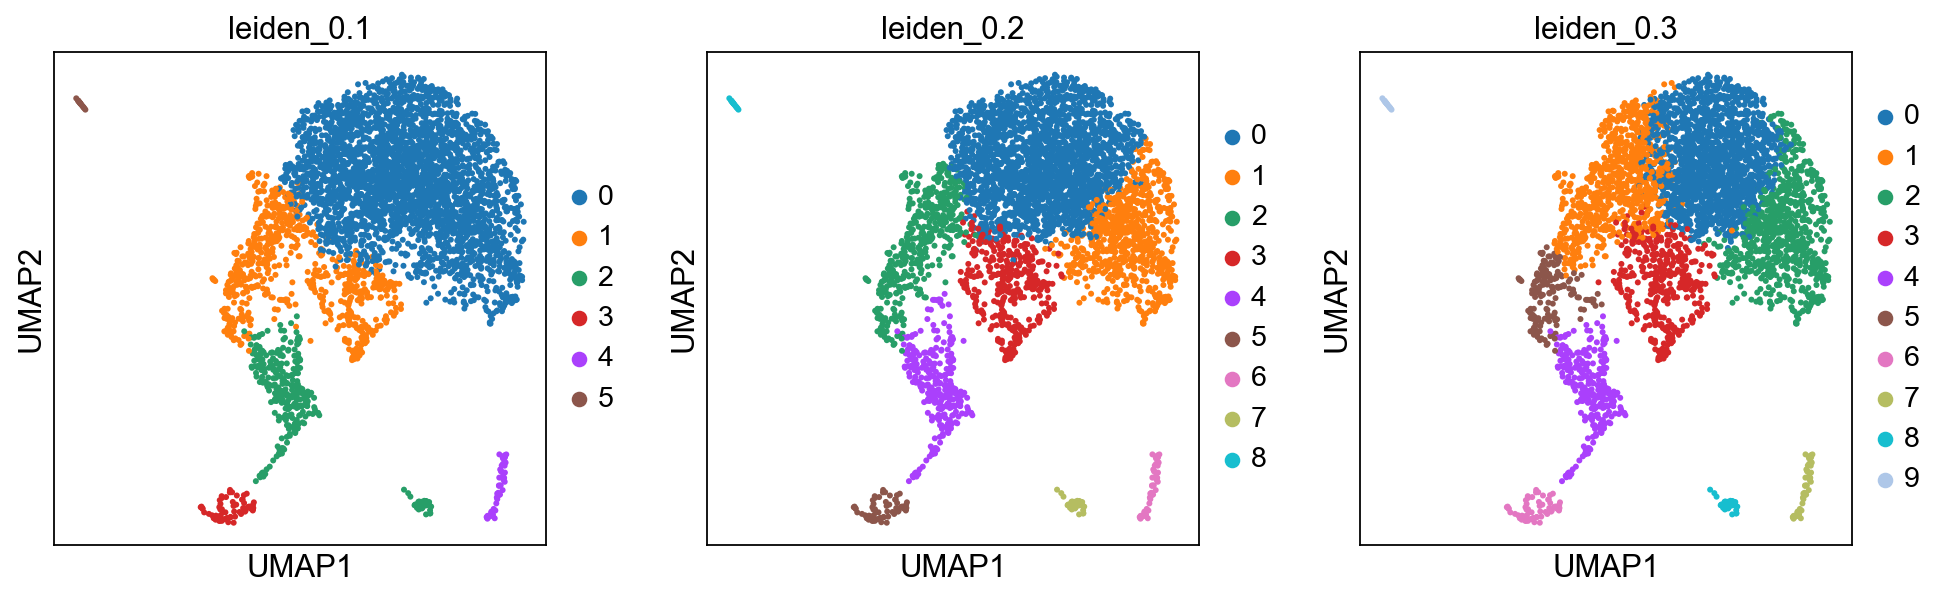

In [57]:
sc.pl.umap(adata, color=['leiden_0.1','leiden_0.2','leiden_0.3'])

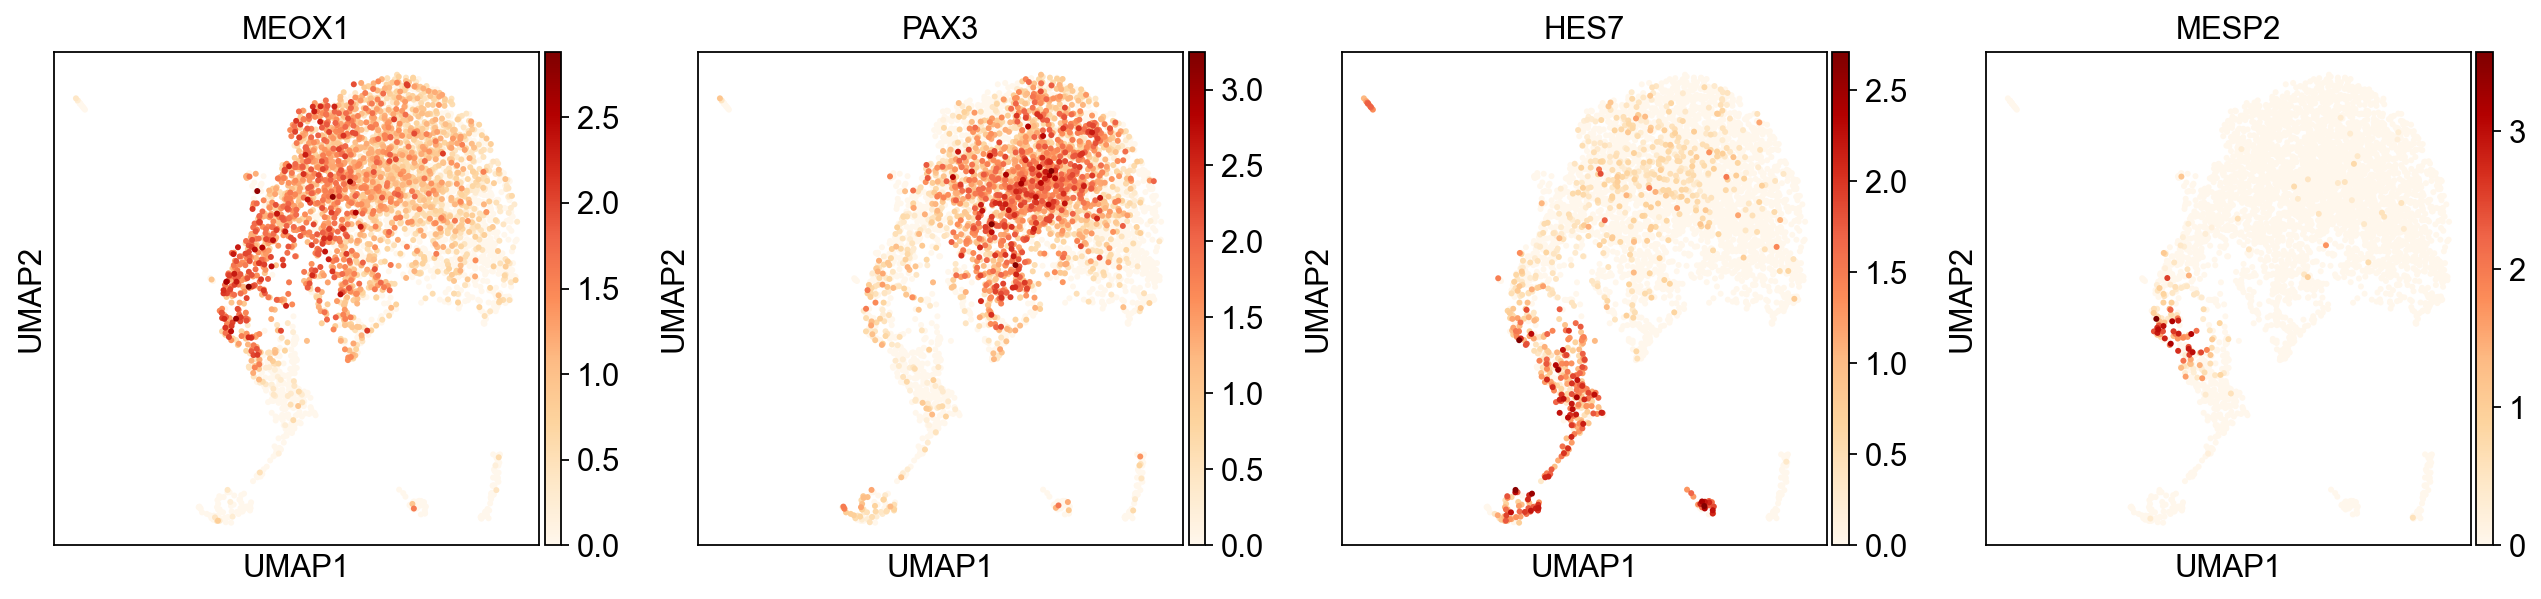

In [58]:
sc.pl.umap(adata, color=['MEOX1','PAX3','HES7','MESP2'],color_map="OrRd")

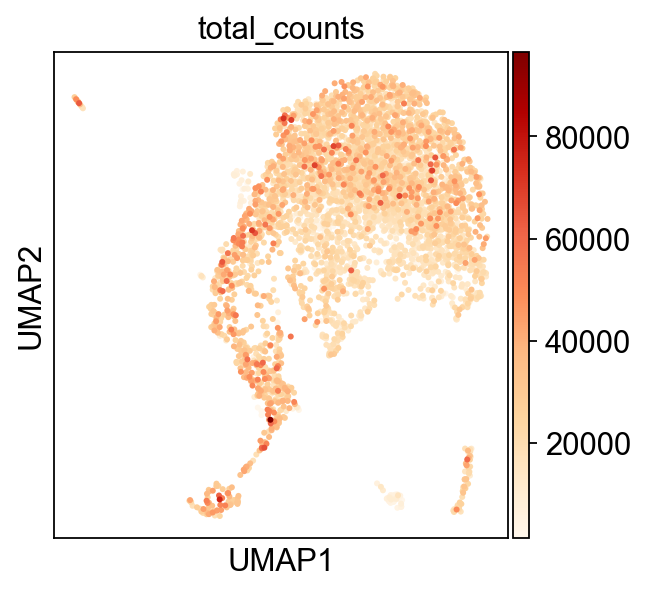

In [59]:
sc.pl.umap(adata, color="total_counts",color_map="OrRd")

In [60]:
genes  = ["NKX1-2","SOX2","CDX2","CDX4", "TBXT",  # NMP
          "TBX6","MSGN1","HES7","MESP1","MESP2","MEOX1","RIPPLY1","FOXC2","MEOX2","ALDH1A2", 'PAX3','TCF15',"SIX1","EYA1","EYA2",  #Mesoderm
          "FOXA2", "NOTO","SHH",  #notochord
          "PAX6","MAP2", #dorsal neural
          "JAG1","PAX8","PAX2",  "GDNF", #nephric
          "TBX1","TWIST1", # anteriorParaxialMesoderm, TCF21 is absent
          "KDR","SOX17", "CD34"  # endothelial
         ]

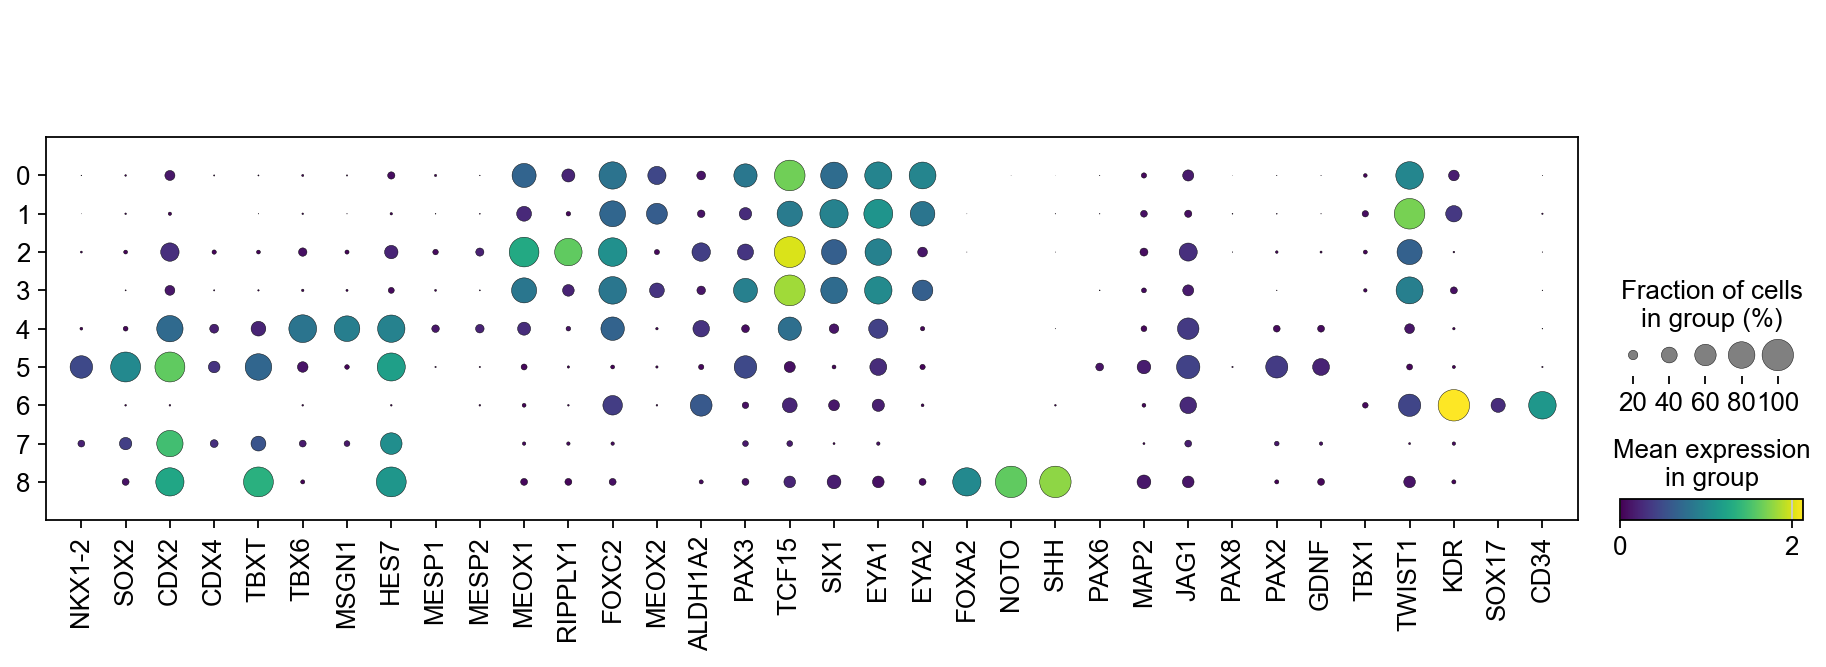

In [61]:
sc.pl.dotplot(adata, genes, groupby='leiden_0.2',color_map="viridis")

In [62]:
adata.write_h5ad('H5AD/20241113_HOXKO_qc_filtered_dr_clustered.h5ad')

## Differential gene expression

In [63]:
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy
import matplotlib.pyplot as plt

sc.settings.verbosity = 2             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()


In [64]:
adata = sc.read_h5ad('H5AD/20241113_HOXKO_qc_filtered_dr_clustered.h5ad')

In [65]:
print(adata.X.shape) #log norm counts 
print(adata.raw.X.shape)  #log norm counts
print(adata.raw.X[:10,:10])

(4124, 27222)
(4124, 27222)
  (2, 1)	0.42701777815818787
  (0, 4)	0.3486010730266571
  (5, 4)	0.6657679080963135
  (8, 4)	0.44470882415771484
  (3, 5)	0.6416028738021851
  (6, 6)	0.5139382481575012


## Wilcoxon rank-sum

ranking genes
    finished (0:00:14)


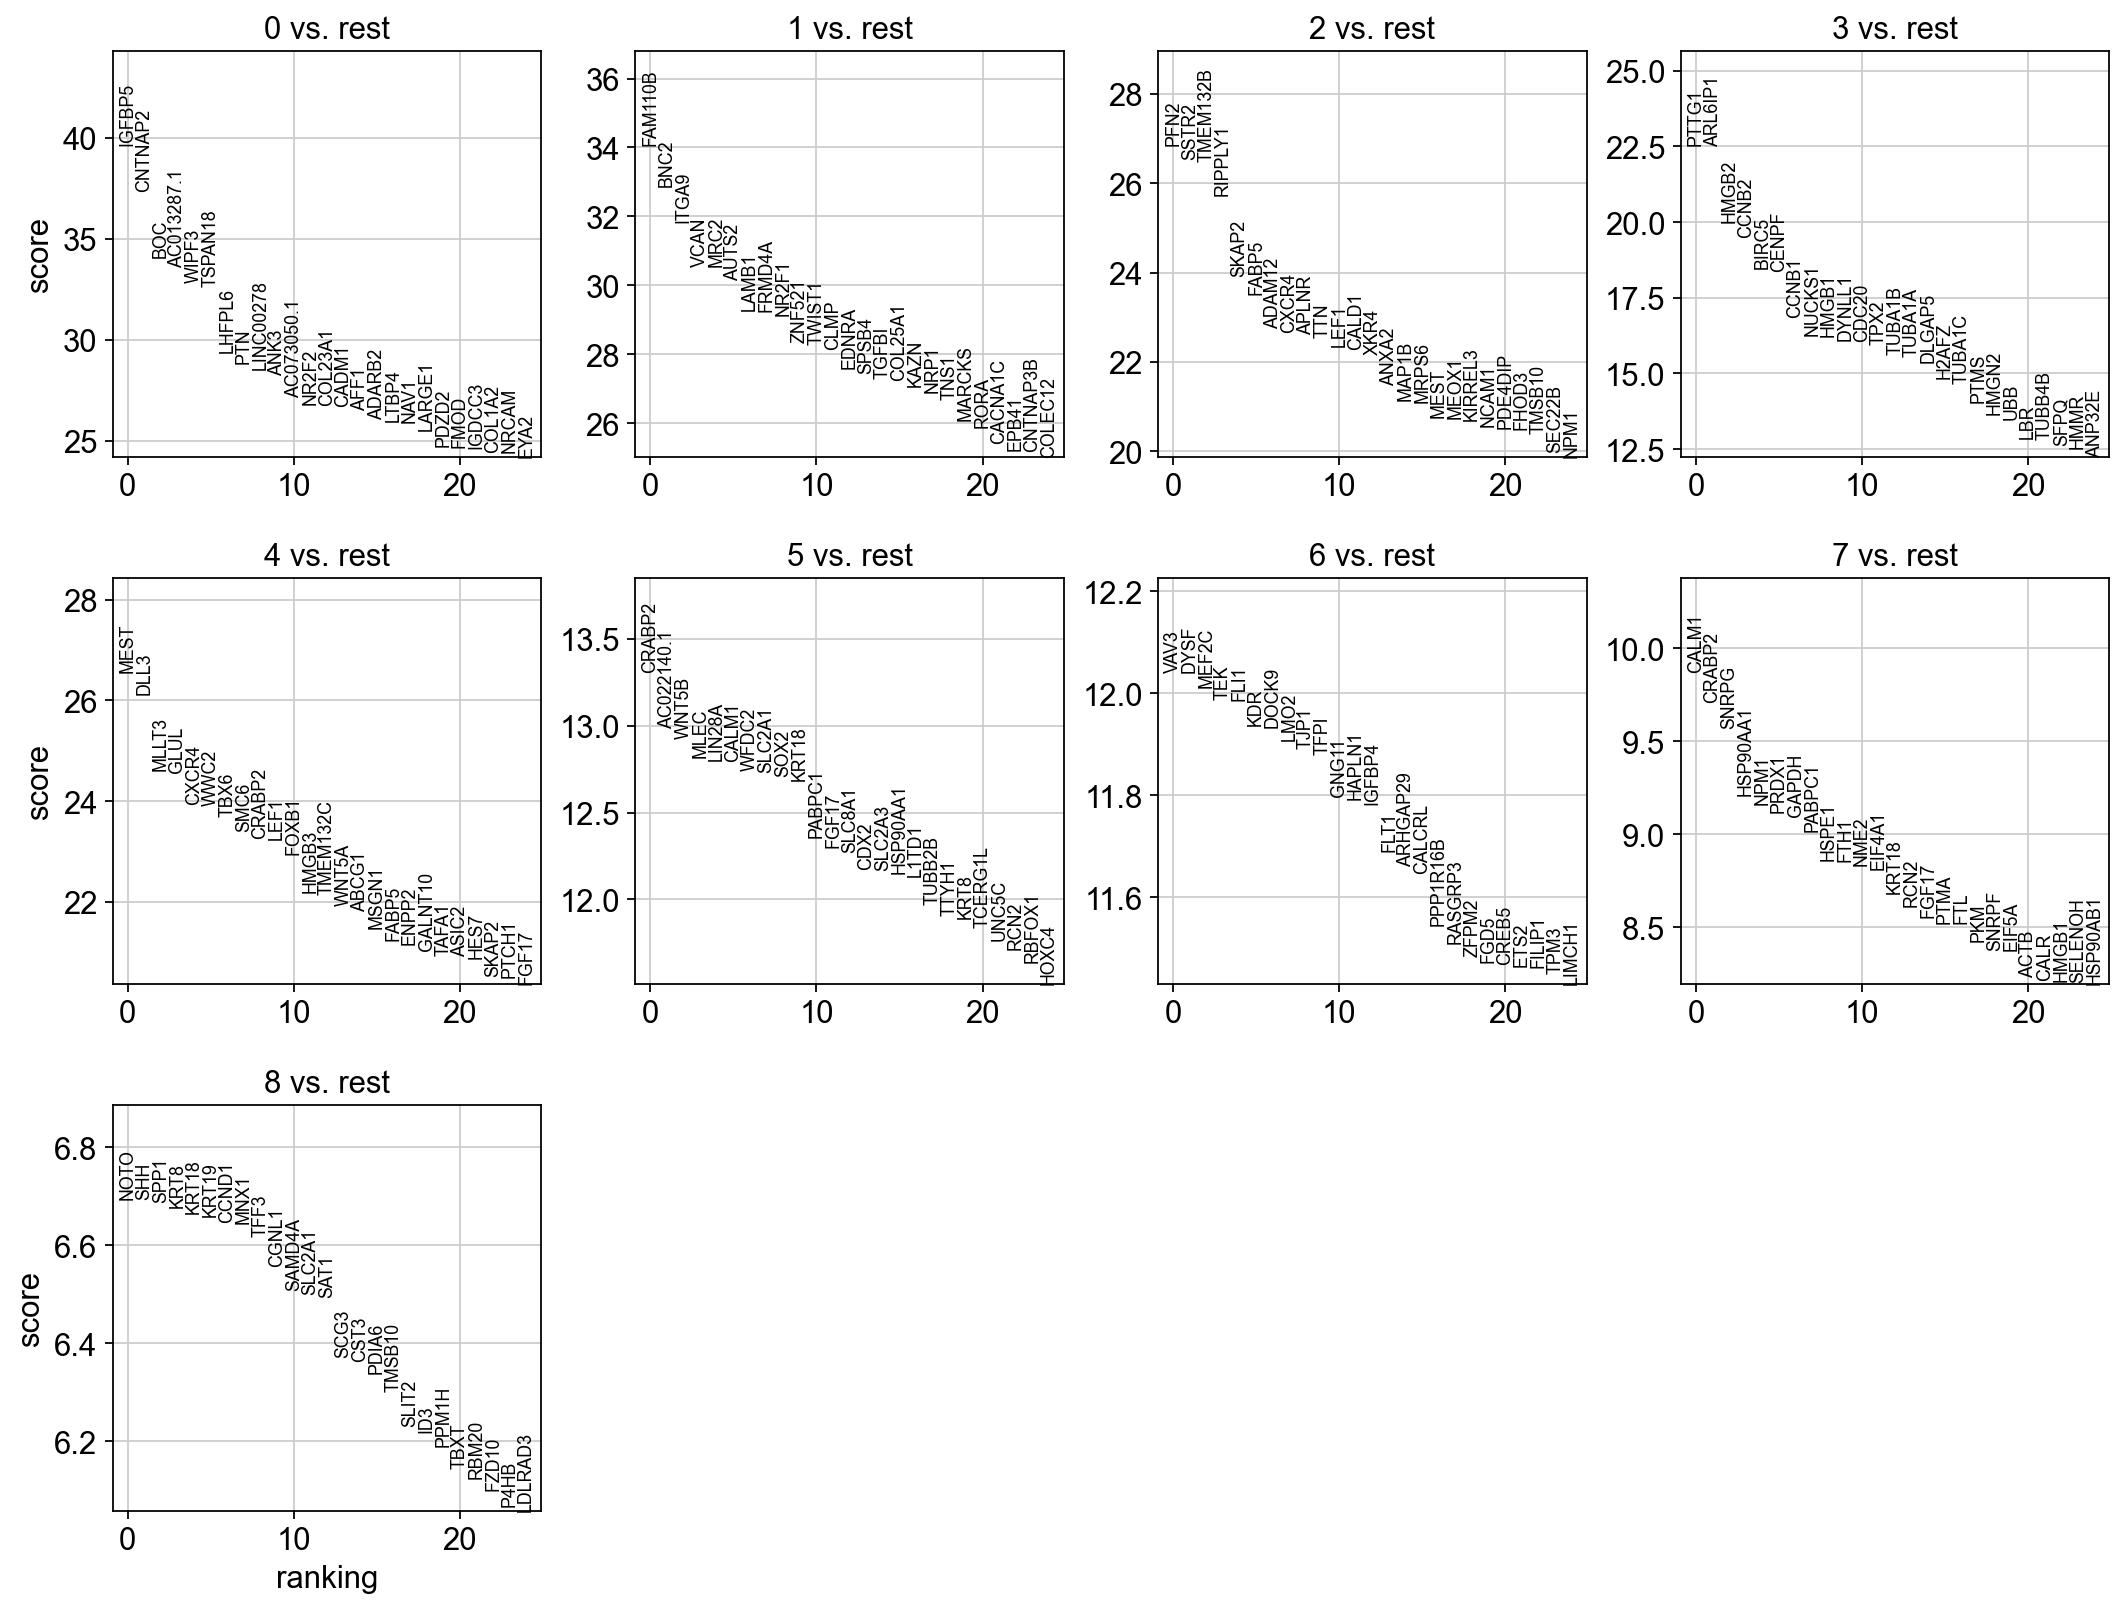

In [66]:
sc.tl.rank_genes_groups(adata, 'leiden_0.2', method='wilcoxon', key_added = "wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key="wilcoxon")

## Annotation

In [67]:
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy
import matplotlib.pyplot as plt

sc.settings.verbosity = 2             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()


In [68]:
adata.obs['annotation'] = adata.obs['leiden_0.2'].copy()

In [69]:
new_cluster_names = [
    'Somite_1', 'Head_Mesoderm','aPSM','Somite_2', 'pPSM',
    'NMP', 'Endothelia','Unknown','Notochord']
adata.rename_categories('annotation', new_cluster_names)

In [70]:
adata.obs['annotation'] = adata.obs['annotation'].cat.reorder_categories(['NMP','pPSM','aPSM',"Somite_1",
                     'Somite_2','Head_Mesoderm','Endothelia', 'Notochord', 'Unknown'])

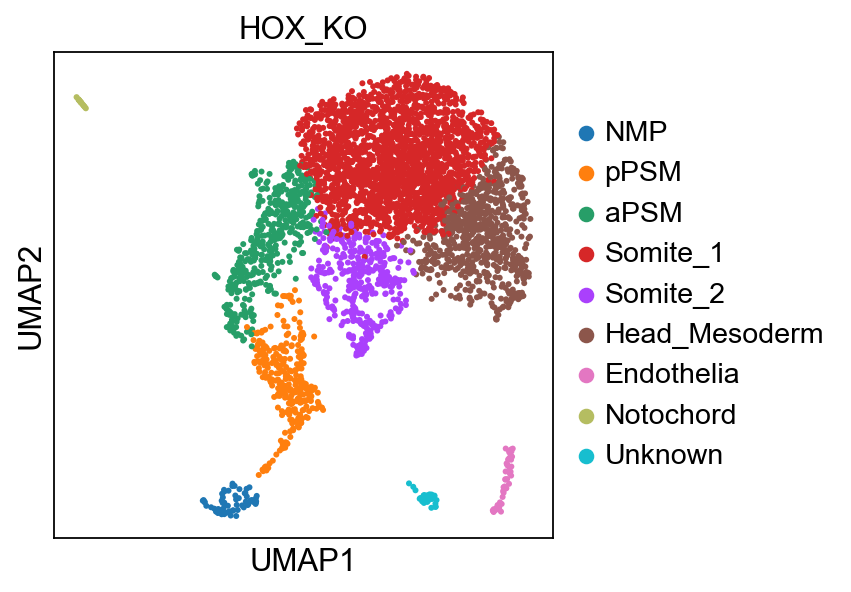

In [71]:
sc.pl.umap(adata, color='annotation', title='HOX_KO', save="20241113_HOXKO_UMAP_clustering.pdf")

ranking genes
    finished (0:00:14)


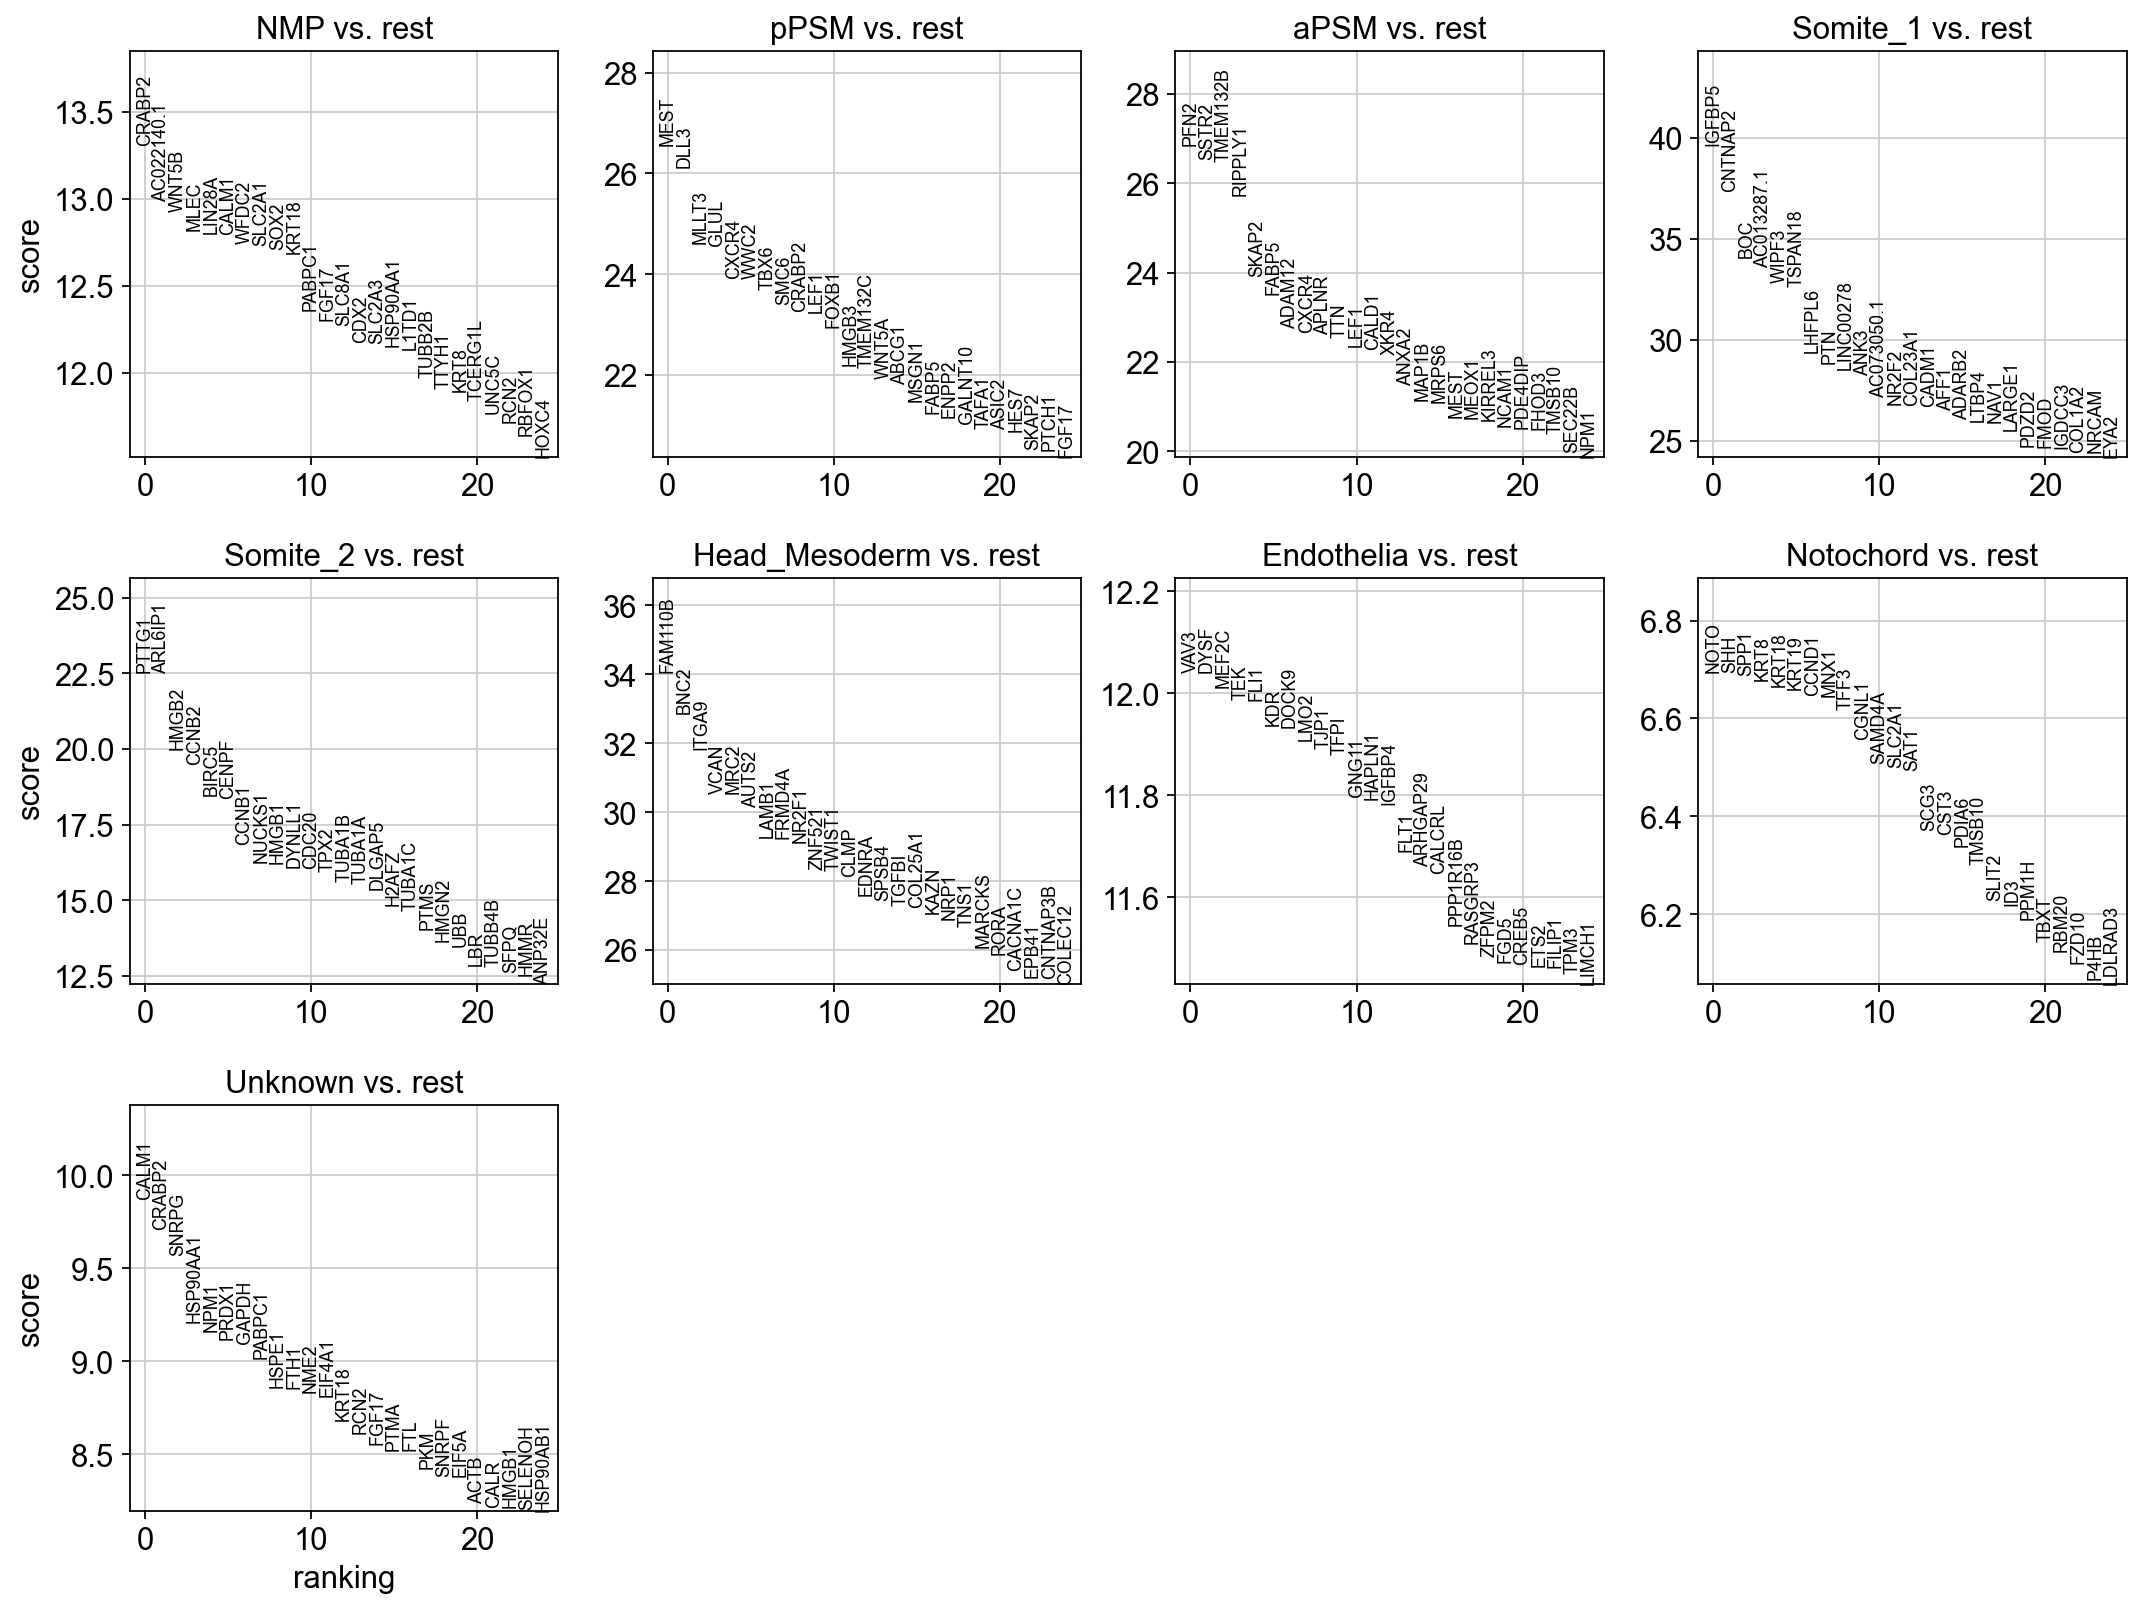

In [72]:
sc.tl.rank_genes_groups(adata, 'annotation', method='wilcoxon', key_added = "wilcoxon_annotation")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key="wilcoxon_annotation")

In [73]:
# getting the list of DEG
result = adata.uns['wilcoxon_annotation']
groups = result['names'].dtype.names
df = pd.DataFrame(
{group + '_' + key[:1]: result[key][group]
for group in groups for key in ['names','logfoldchanges','pvals','pvals_adj']})
df.to_csv('CSV/20241113_HOXKOanalysis_wilcoxon.csv')

In [74]:
adata.write_h5ad("H5AD/20241113_HOXKO_qc_filtered_dr_clustered_ano.h5ad")

## Downstream Analysis

In [75]:
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy
import matplotlib.pyplot as plt

sc.settings.verbosity = 2             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()

In [76]:
adata = sc.read_h5ad('H5AD/20241113_HOXKO_qc_filtered_dr_clustered_ano.h5ad')

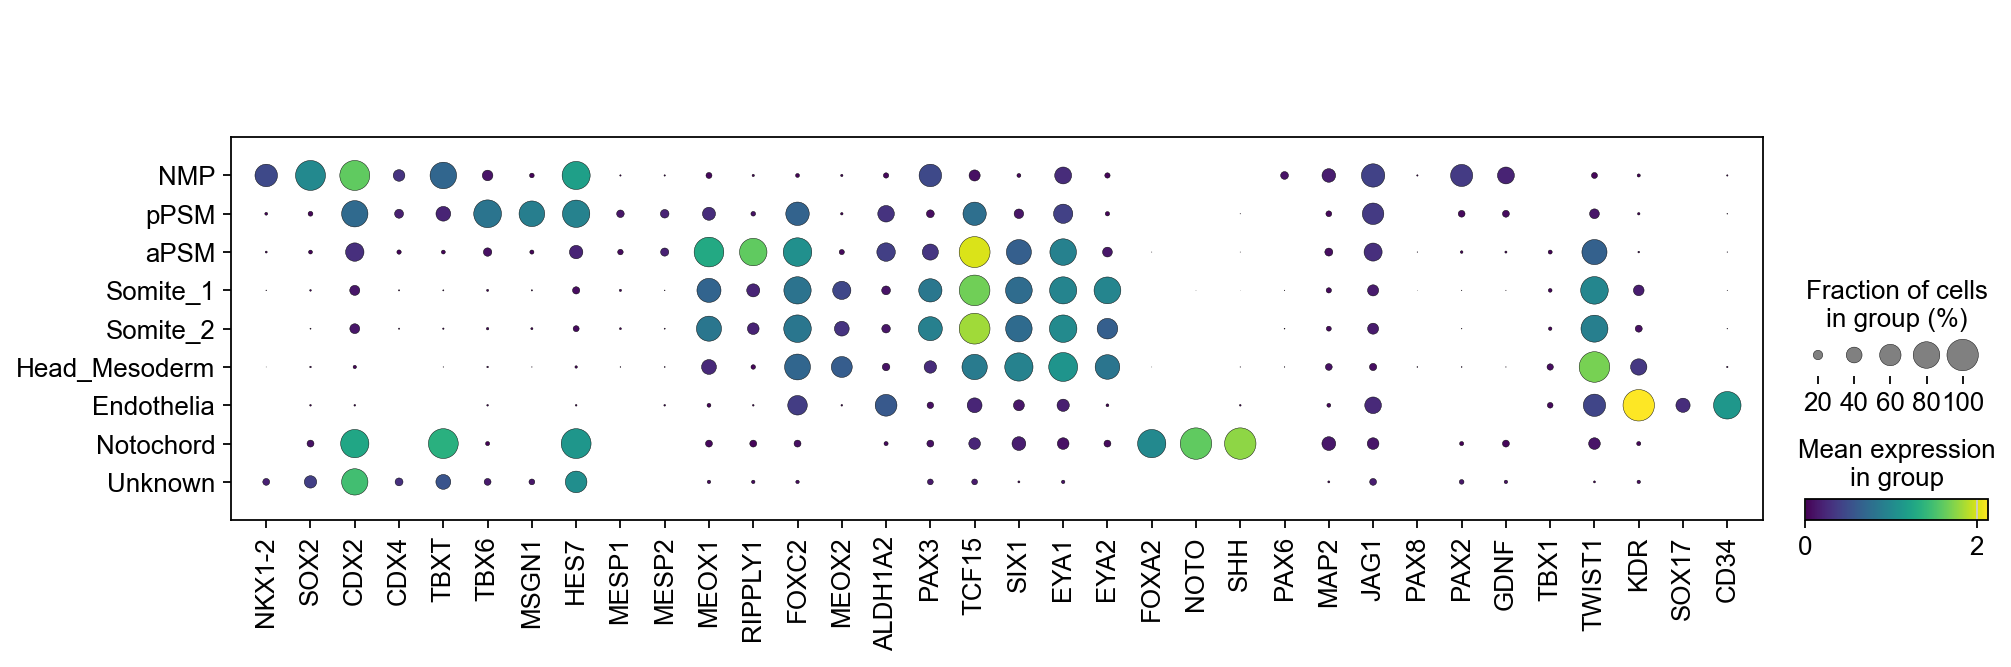

In [77]:
sc.pl.dotplot(adata, genes, groupby='annotation',color_map="viridis", save="20241113_HOXKO_dotplot_markergenes.pdf")

If you want the same plot with scaled values

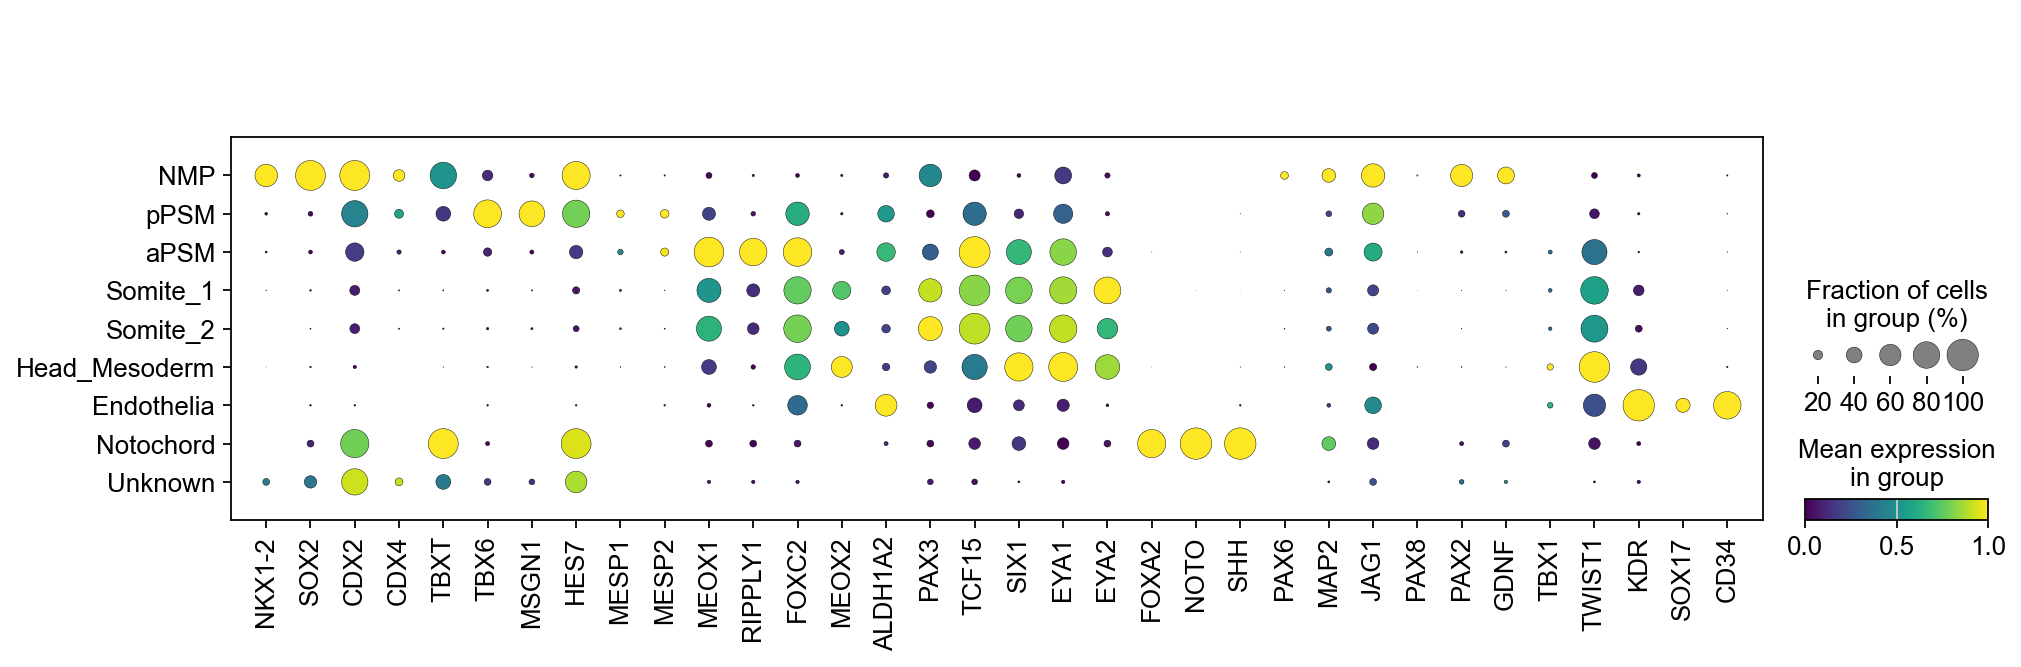

In [78]:
sc.pl.dotplot(adata, genes, groupby='annotation', color_map="viridis", standard_scale="var", save="20241113_HOXKO_dotplot_markergenes_std.pdf")

In [79]:
all_hox_genes= [ "HOXA1","HOXA2", "HOXA3", "HOXA4", "HOXA5","HOXA6","HOXA7","HOXA8","HOXA9","HOXA10","HOXA11", "HOXA12","HOXA13",
                 "HOXB1","HOXB2", "HOXB3", "HOXB4", "HOXB5","HOXB6","HOXB7","HOXB8","HOXB9","HOXB10","HOXB11", "HOXB12","HOXB13",
                 "HOXC1","HOXC2", "HOXC3", "HOXC4", "HOXC5","HOXC6","HOXC7","HOXC8","HOXC9","HOXC10","HOXC11","HOXC12","HOXC13",
                 "HOXD1","HOXD2", "HOXD3", "HOXD4", "HOXD5","HOXD6","HOXD7","HOXD8","HOXD9","HOXD10","HOXD11","HOXD12", "HOXD13"]

In [80]:
# Let's check which HOX genes are not expressed
gene_of_interest = all_hox_genes

for gene in gene_of_interest:
    if gene in adata.var_names:
        print(f"Gene {gene} found in the dataset.")
        continue

Gene HOXB1 found in the dataset.
Gene HOXB13 found in the dataset.
Gene HOXC4 found in the dataset.
Gene HOXC13 found in the dataset.
Gene HOXD1 found in the dataset.
Gene HOXD13 found in the dataset.


Remanent expression of HOX is minimal and likely be due to deletion strategy

### Some markers for the Head mesoderm cluster

In [81]:
Head_Mesoderm_genes=["TBX1","TWIST1",  #posterior Head mesoderm
                     "PITX2","ALX4",  #anterior head mesoderm
                     "ISL1","FGF8", #cardiac mesoderm
                      "MSC", #cranial muscle progenitors, TCF21 is missing
                     "KDR", "VEGFC" #vasculogenesis
                    ]

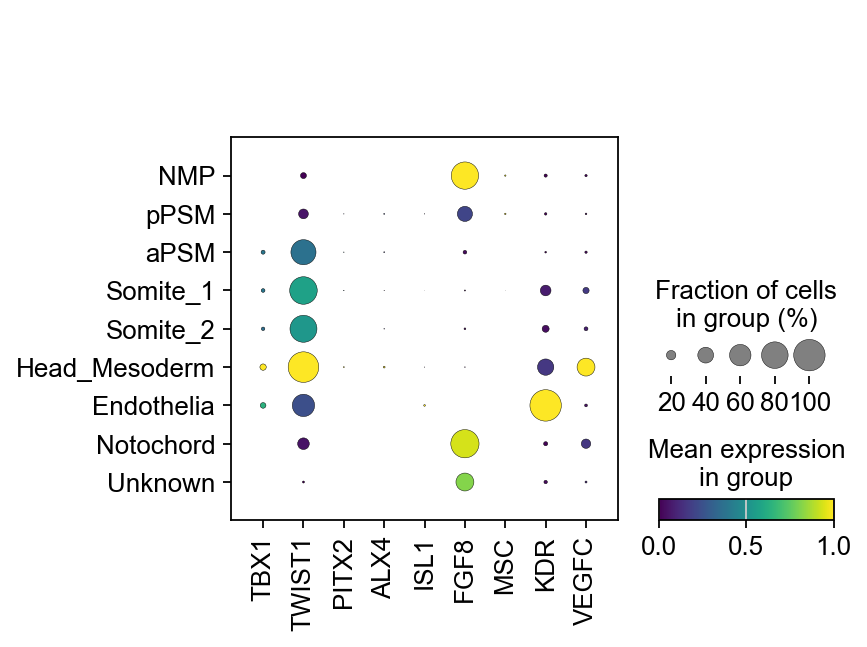

In [82]:
sc.pl.dotplot(adata, Head_Mesoderm_genes, groupby='annotation',color_map="viridis", standard_scale="var", save="20241113_HOXKO_HeadmesodermGenes_dotplot_std.pdf")

#####  No significant upregulated expression of ISL1, NKX2-5, ALX4, PITX2, FGF8

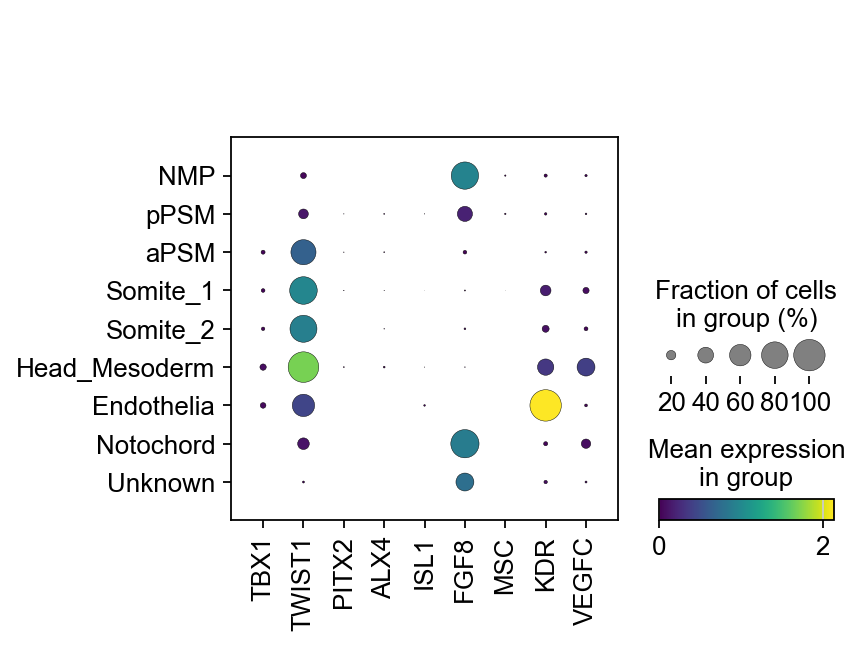

In [83]:
sc.pl.dotplot(adata, Head_Mesoderm_genes, groupby='annotation',color_map="viridis", save="20241113_HOXKO_HeadmesodermGenes_dotplot.pdf")

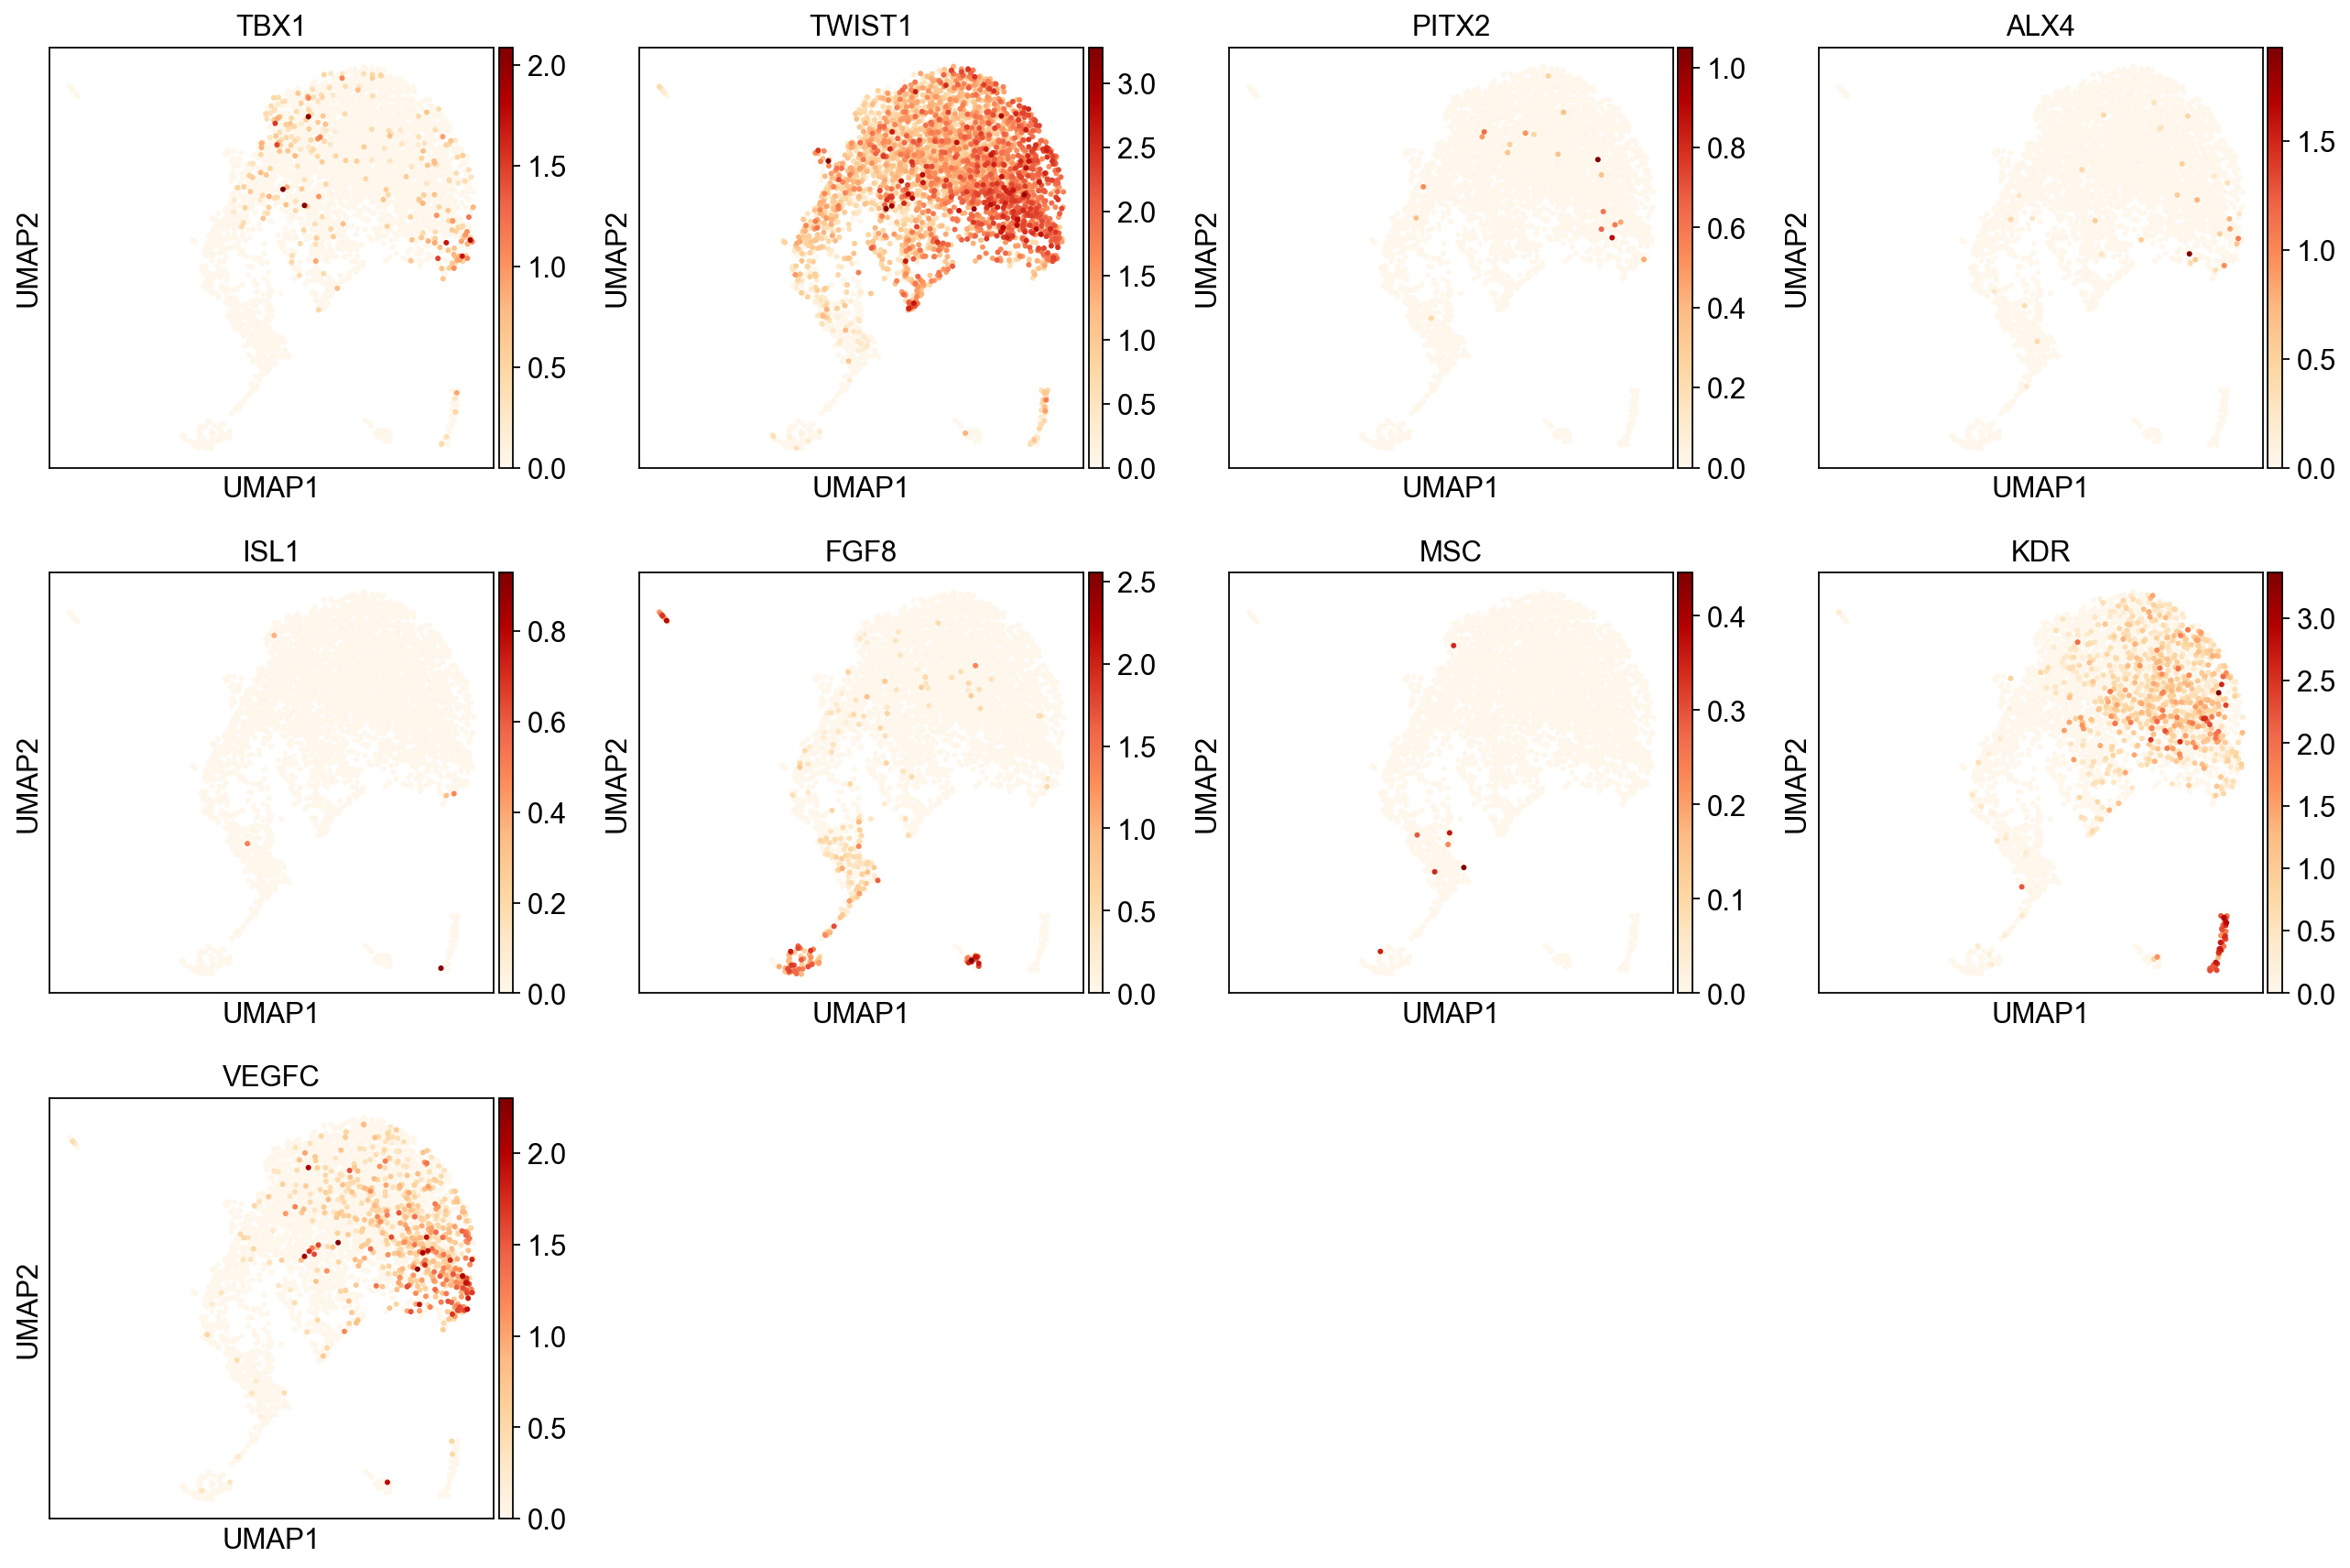

In [84]:
sc.pl.umap(adata, color=Head_Mesoderm_genes, color_map ="OrRd")

In [85]:
# check that the matrix looks like normalized counts
print(adata.X[1:10,1:10])

  (1, 0)	0.42701777815818787
  (4, 3)	0.6657679080963135
  (7, 3)	0.44470882415771484
  (2, 4)	0.6416028738021851
  (5, 5)	0.5139382481575012


In [86]:
print(adata.raw.X[1:10,1:10]) 

  (1, 0)	0.42701777815818787
  (4, 3)	0.6657679080963135
  (7, 3)	0.44470882415771484
  (2, 4)	0.6416028738021851
  (5, 5)	0.5139382481575012


## PAGA analysis

In [87]:
# For the PAGA analysis the Paraxial Mesoderm clusters were subsetted 

In [88]:
adata_subset = adata[adata.obs['annotation'].isin(['NMP', 'pPSM','aPSM','Somite_1',
                     'Somite_2', 'Head_Mesoderm'])].copy()

In [89]:
# For simplicity we will fuse the 2 somite clusters into 1 single cluster

In [90]:
adata_subset.obs['annotation_short'] = (
    adata_subset.obs["annotation"]
    .map(lambda x: {"Somite_1": "Somite", "Somite_2": "Somite"}.get(x, x))
    .astype("category")
)

In [91]:
adata_subset.obs['annotation_short'] = adata_subset.obs['annotation_short'].cat.reorder_categories(['NMP','pPSM','aPSM','Somite',
                     'Head_Mesoderm'])

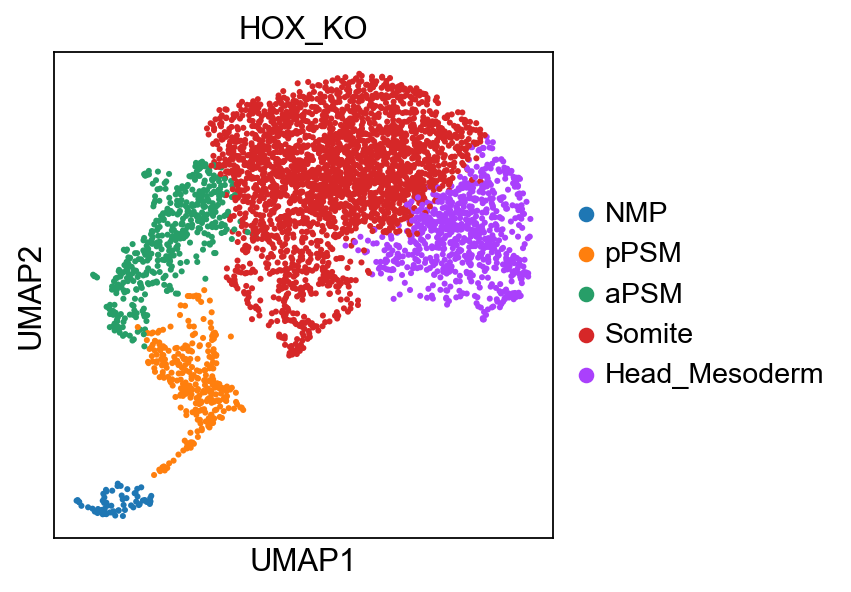

In [92]:
sc.pl.umap(adata_subset, color='annotation_short', title='HOX_KO', save="20241113_HOXKO_UMAP_clustering_PSMsubset.pdf")

In [93]:
sc.tl.draw_graph(adata_subset)

drawing single-cell graph using layout 'fa'
    finished (0:00:42)


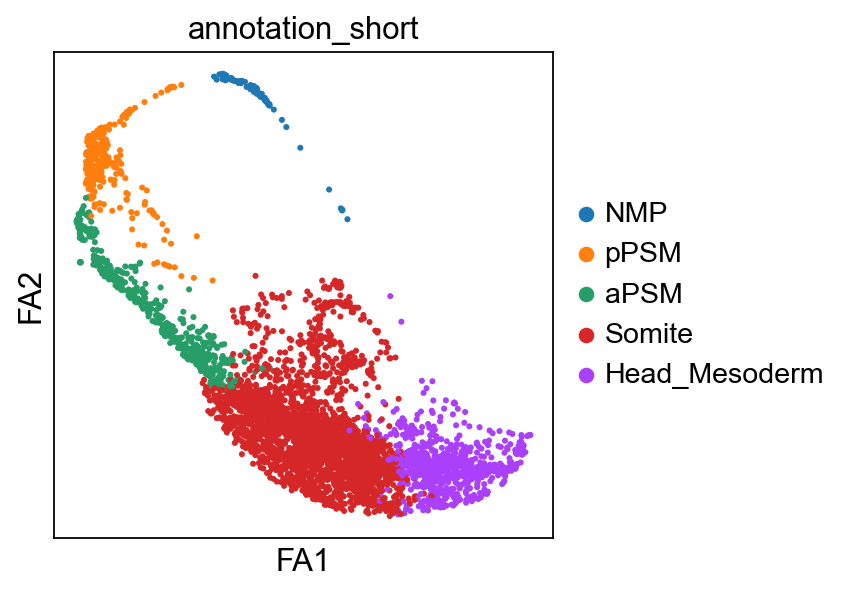

In [94]:
sc.pl.draw_graph(adata_subset, color="annotation_short")

In [95]:
sc.tl.paga(adata_subset, groups="annotation_short")

running PAGA
    finished (0:00:00)


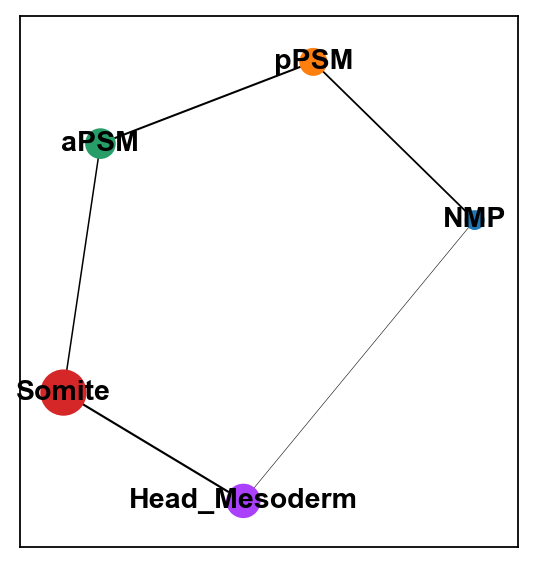

In [96]:
sc.pl.paga(adata_subset, color=["annotation_short"], save="20241113_HOXKO_PMclusters_PAGA_analysis.pdf")

### Recomputing the embedding using PAGA-initialization

In [97]:
sc.tl.draw_graph(adata_subset, init_pos="paga")

drawing single-cell graph using layout 'fa'
    finished (0:00:42)


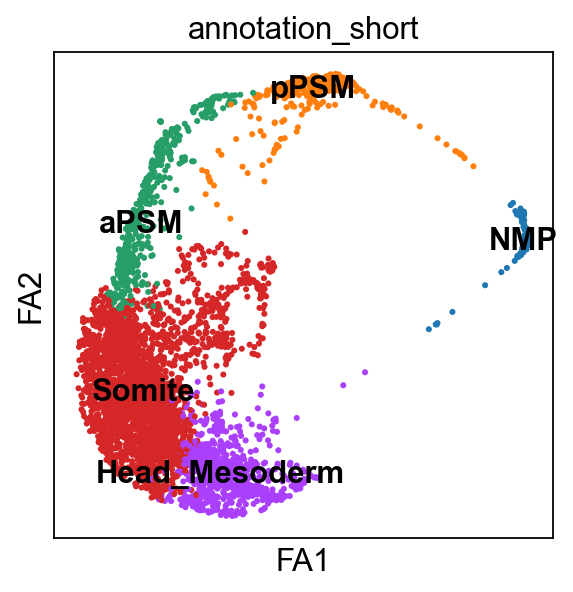

In [98]:
sc.pl.draw_graph(
    adata_subset, color=["annotation_short"], legend_loc="on data", color_map="OrRd"
)

## Pseudotime analysis

NMP cluster was selected as the root cell for pseudotime analysis

In [99]:
adata_subset.uns["iroot"] = np.flatnonzero(adata_subset.obs["annotation_short"] == "NMP")[0]

In [100]:
sc.tl.dpt(adata_subset)

computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.99750304 0.99581367 0.9881496  0.9820757  0.9807022
     0.9729948  0.971637   0.96584666 0.96282315 0.9607158  0.95705575
     0.95572543 0.9539629  0.9500131 ]
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)


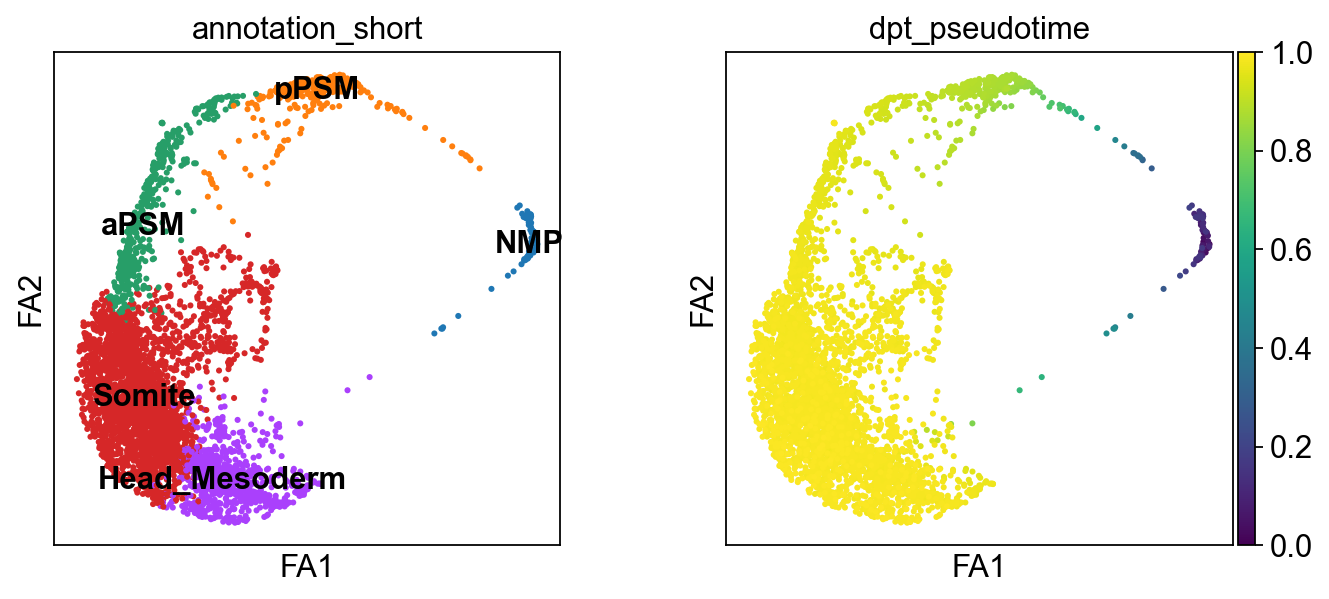

In [101]:
sc.pl.draw_graph(adata_subset, color=["annotation_short", "dpt_pseudotime"],legend_loc="on data", save="20241113_HOXKO_PMclusters_pseudotime.pdf")

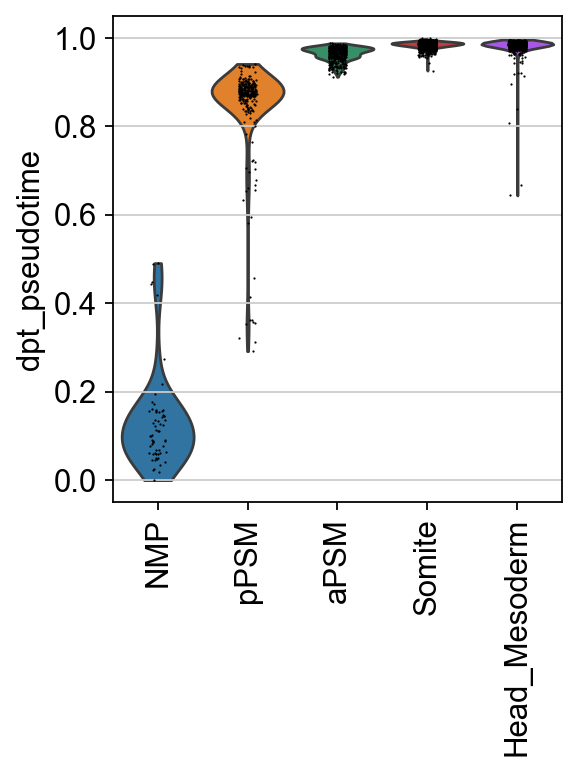

In [102]:
sc.pl.violin(adata_subset, "dpt_pseudotime", groupby="annotation_short", rotation=90, save="20241113_HOXKO_PMclusters_Pseudotime_Violinplot.pdf")